<a href="https://colab.research.google.com/github/palakbari/Machine-Learning/blob/main/CyberLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement:


# Step 1: Load and understand the dataset

CICIDS2017 is selected as the primary dataset for the CyberLens framework because it is specifically designed for network intrusion-detection research and provides both benign and malicious network-flow records with diverse attack scenarios. The dataset contains network-level features suitable for ML-based classification, feature selection, class-imbalance analysis, and explainable prediction. Its inclusion of DDoS, brute-force, port-scanning, botnet, and web-based attack traffic makes it particularly suitable for the attack categories considered in this project.
Alternative datasets such as NSL-KDD, UNSW-NB15, CSE-CIC-IDS2018, and CIC-DDoS2019 were not included because they differ in traffic characteristics, attack composition, or research focus.


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
DATA_PATH = "/content/drive/MyDrive/CyberLens"

In [ ]:
import pandas as pd
import os
import glob

# Get all CSV files
csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))

print("Number of CSV files found:", len(csv_files))
print()

for file in csv_files:

    print("=" * 80)
    print("FILE:", os.path.basename(file))
    print("=" * 80)

    # Read the CSV
    df = pd.read_csv(file, encoding='latin1')

    print("Number of records:", len(df))
    print("Number of columns:", len(df.columns))
    print()

    # Print columns to debug KeyError
    print("DataFrame Columns:", df.columns.tolist())

    # Display label distribution
    print("Label Distribution:")
    print(df[' Label'].value_counts())

    print()

Number of CSV files found: 8

FILE: Wednesday-workingHours.pcap_ISCX.csv
Number of records: 692703
Number of columns: 79

DataFrame Columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Leng

In [ ]:
report = []

for file in csv_files:

    filename = os.path.basename(file)

    df = pd.read_csv(file, encoding='latin1')

    label_counts = df[' Label'].value_counts()

    for label, count in label_counts.items():

        report.append({
            'File': filename,
            'Label': label,
            'Count': count
        })

label_report = pd.DataFrame(report)

label_report

,File,Label,Count
0,Wednesday-workingHours.pcap_ISCX.csv,BENIGN,440031
1,Wednesday-workingHours.pcap_ISCX.csv,DoS Hulk,231073
2,Wednesday-workingHours.pcap_ISCX.csv,DoS GoldenEye,10293
3,Wednesday-workingHours.pcap_ISCX.csv,DoS slowloris,5796
4,Wednesday-workingHours.pcap_ISCX.csv,DoS Slowhttptest,5499
5,Wednesday-workingHours.pcap_ISCX.csv,Heartbleed,11
6,Tuesday-WorkingHours.pcap_ISCX.csv,BENIGN,432074
7,Tuesday-WorkingHours.pcap_ISCX.csv,FTP-Patator,7938
8,Tuesday-WorkingHours.pcap_ISCX.csv,SSH-Patator,5897
9,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,BENIGN,168186


In [ ]:
total_label_counts = (
    label_report
    .groupby('Label')['Count']
    .sum()
    .sort_values(ascending=False)
)

print("Total records by label:")
print(total_label_counts)

Total records by label:
Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: Count, dtype: int64


In [ ]:
unique_labels = sorted(label_report['Label'].unique())

print("Unique labels found:")
for i, label in enumerate(unique_labels, 1):
    print(f"{i}. {label}")

Unique labels found:
1. BENIGN
2. Bot
3. DDoS
4. DoS GoldenEye
5. DoS Hulk
6. DoS Slowhttptest
7. DoS slowloris
8. FTP-Patator
9. Heartbleed
10. Infiltration
11. PortScan
12. SSH-Patator
13. Web Attack ï¿½ Brute Force
14. Web Attack ï¿½ Sql Injection
15. Web Attack ï¿½ XSS


In [ ]:
# Show where every attack label is located

for file in csv_files:

    df_temp = pd.read_csv(file, encoding='latin1')

    labels = df_temp[' Label'].value_counts()

    print("\n" + "=" * 80)
    print(os.path.basename(file))
    print("=" * 80)

    for label, count in labels.items():
        if label != 'BENIGN':
            print(f"{label:<35} {count:,}")


Wednesday-workingHours.pcap_ISCX.csv
DoS Hulk                            231,073
DoS GoldenEye                       10,293
DoS slowloris                       5,796
DoS Slowhttptest                    5,499
Heartbleed                          11

Tuesday-WorkingHours.pcap_ISCX.csv
FTP-Patator                         7,938
SSH-Patator                         5,897

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Web Attack ï¿½ Brute Force          1,507
Web Attack ï¿½ XSS                  652
Web Attack ï¿½ Sql Injection        21

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Infiltration                        36

Monday-WorkingHours.pcap_ISCX.csv

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
PortScan                            158,930

Friday-WorkingHours-Morning.pcap_ISCX.csv
Bot                                 1,966

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
DDoS                                128,027


# Step 2: Create Combined Dataset

The 8 CSV files represent different portions of the CICIDS2017 dataset, with different files containing different traffic and attack scenarios. Since CyberLens is designed as a multi-class network intrusion detection system, we need a unified dataset containing all the relevant classes—Normal, DDoS, Brute Force, Port Scan, Botnet, and Web Attack. Therefore, we selected the records relevant to our research scope, standardized their labels, and consolidated them into a single experimental dataset. The original CSV files were retained unchanged as the raw source data.

In [ ]:
import os
import pandas as pd
import glob

RAW_PATH = "/content/drive/MyDrive/CyberLens/"
PROCESSED_PATH = "/content/drive/MyDrive/CyberLens"

os.makedirs(PROCESSED_PATH, exist_ok=True)

output_file = os.path.join(
    PROCESSED_PATH,
    "CyberLens_Combined_Raw.csv"
)

print("Output file:", output_file)

Output file: /content/drive/MyDrive/CyberLens/CyberLens_Combined_Raw.csv


DoS Hulk,
DoS GoldenEye,
DoS slowloris,
DoS Slowhttptest

These are excluded because our research scope specifically defines DDoS rather than the broader DoS category.

Infiltration,
Heartbleed

Are excluded because they aren't among the six attack categories defined in our CyberLens research objectives.

In [ ]:
selected_files = {
    "Monday-WorkingHours.pcap_ISCX.csv": ["BENIGN"],

    "Tuesday-WorkingHours.pcap_ISCX.csv": [
        "BENIGN",
        "FTP-Patator",
        "SSH-Patator"
    ],

    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv": [
        "BENIGN",
        "Web Attack"
    ],

    "Friday-WorkingHours-Morning.pcap_ISCX.csv": [
        "BENIGN",
        "Bot"
    ],

    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv": [
        "BENIGN",
        "PortScan"
    ],

    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv": [
        "BENIGN",
        "DDoS"
    ]
}

In [ ]:
def map_cyberlens_label(label):

    label = str(label).strip()

    # Normal traffic
    if label == "BENIGN":
        return "Normal"

    # DDoS
    elif label == "DDoS":
        return "DDoS"

    # Brute Force
    elif label in ["FTP-Patator", "SSH-Patator"]:
        return "Brute Force"

    # Port Scanning
    elif label == "PortScan":
        return "Port Scan"

    # Botnet
    elif label == "Bot":
        return "Botnet"

    # Web attacks
    elif "Web Attack" in label:
        return "Web Attack"

    # Anything else
    else:
        return None

In [ ]:
# Remove previous output if it exists
if os.path.exists(output_file):
    os.remove(output_file)

first_chunk = True

for filename, allowed_labels in selected_files.items():

    filepath = os.path.join(RAW_PATH, filename)

    print("\n" + "=" * 80)
    print("Processing:", filename)
    print("=" * 80)

    if not os.path.exists(filepath):
        print("WARNING: File not found!")
        continue

    file_rows = 0
    selected_rows = 0

    for chunk in pd.read_csv(
        filepath,
        encoding="latin1",
        chunksize=50000,
        low_memory=False
    ):

        file_rows += len(chunk)

        # Keep only required records
        if "BENIGN" in allowed_labels:
            mask = chunk[" Label"].isin(allowed_labels) | (
                chunk[" Label"].astype(str).str.contains(
                    "Web Attack",
                    na=False
                ) & chunk[" Label"].astype(str).str.startswith(
                    "Web Attack",
                    na=False
                )
            )
        else:
            mask = chunk[" Label"].isin(allowed_labels)

        selected_chunk = chunk.loc[mask].copy()

        if len(selected_chunk) == 0:
            continue

        # Convert original labels to CyberLens labels
        selected_chunk["CyberLens_Label"] = (
            selected_chunk[" Label"].apply(map_cyberlens_label)
        )

        # Remove anything that wasn't mapped
        selected_chunk = selected_chunk.dropna(
            subset=["CyberLens_Label"]
        )

        selected_rows += len(selected_chunk)

        # Append to combined CSV
        selected_chunk.to_csv(
            output_file,
            mode="w" if first_chunk else "a",
            header=first_chunk,
            index=False
        )

        first_chunk = False

    print("Original rows:", f"{file_rows:,}")
    print("Selected rows:", f"{selected_rows:,}")

print("\n" + "=" * 80)
print("COMBINATION COMPLETED")
print("=" * 80)
print("Saved to:")
print(output_file)


Processing: Monday-WorkingHours.pcap_ISCX.csv
Original rows: 529,918
Selected rows: 529,918

Processing: Tuesday-WorkingHours.pcap_ISCX.csv
Original rows: 445,909
Selected rows: 445,909

Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Original rows: 170,366
Selected rows: 170,366

Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Original rows: 191,033
Selected rows: 191,033

Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Original rows: 286,467
Selected rows: 286,467

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Original rows: 225,745
Selected rows: 225,745

COMBINATION COMPLETED
Saved to:
/content/drive/MyDrive/CyberLens/processed/CyberLens_Combined_Raw.csv


In [ ]:
combined = pd.read_csv(
    output_file,
    encoding="latin1",
    low_memory=False
)

print("Dataset shape:", combined.shape)

print("\nCyberLens class distribution:")
print(
    combined["CyberLens_Label"]
    .value_counts()
)

Dataset shape: (1849438, 80)

CyberLens class distribution:
CyberLens_Label
Normal         1544500
Port Scan       158930
DDoS            128027
Brute Force      13835
Web Attack        2180
Botnet            1966
Name: count, dtype: int64


In [ ]:
class_report = (
    combined["CyberLens_Label"]
    .value_counts()
    .rename_axis("CyberLens_Class")
    .reset_index(name="Record_Count")
)

class_report["Percentage"] = (
    class_report["Record_Count"]
    / class_report["Record_Count"].sum()
    * 100
)

class_report

,CyberLens_Class,Record_Count,Percentage
0,Normal,1544500,83.511856
1,Port Scan,158930,8.593421
2,DDoS,128027,6.922481
3,Brute Force,13835,0.748065
4,Web Attack,2180,0.117874
5,Botnet,1966,0.106303


In [ ]:
class_report.to_csv(
    "/content/drive/MyDrive/CyberLens/class_distribution_before_cleaning.csv",
    index=False
)

In [ ]:
print("Dataset shape:", combined.shape)
print(combined["CyberLens_Label"].value_counts())

Dataset shape: (1849438, 80)
CyberLens_Label
Normal         1544500
Port Scan       158930
DDoS            128027
Brute Force      13835
Web Attack        2180
Botnet            1966
Name: count, dtype: int64


# Step 3: Read the Dataset

In [ ]:
import pandas as pd
import numpy as np
import os

COMBINED_PATH = "/content/drive/MyDrive/CyberLens/CyberLens_Combined_Raw.csv"

df = pd.read_csv(
    COMBINED_PATH,
    encoding="latin1",
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1849438, 80)


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 5 rows:")
display(df.head())

Number of rows: 1849438
Number of columns: 80

First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,CyberLens_Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal


In [ ]:
print("\nColumn names:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")


Column names:
1.  Destination Port
2.  Flow Duration
3.  Total Fwd Packets
4.  Total Backward Packets
5. Total Length of Fwd Packets
6.  Total Length of Bwd Packets
7.  Fwd Packet Length Max
8.  Fwd Packet Length Min
9.  Fwd Packet Length Mean
10.  Fwd Packet Length Std
11. Bwd Packet Length Max
12.  Bwd Packet Length Min
13.  Bwd Packet Length Mean
14.  Bwd Packet Length Std
15. Flow Bytes/s
16.  Flow Packets/s
17.  Flow IAT Mean
18.  Flow IAT Std
19.  Flow IAT Max
20.  Flow IAT Min
21. Fwd IAT Total
22.  Fwd IAT Mean
23.  Fwd IAT Std
24.  Fwd IAT Max
25.  Fwd IAT Min
26. Bwd IAT Total
27.  Bwd IAT Mean
28.  Bwd IAT Std
29.  Bwd IAT Max
30.  Bwd IAT Min
31. Fwd PSH Flags
32.  Bwd PSH Flags
33.  Fwd URG Flags
34.  Bwd URG Flags
35.  Fwd Header Length
36.  Bwd Header Length
37. Fwd Packets/s
38.  Bwd Packets/s
39.  Min Packet Length
40.  Max Packet Length
41.  Packet Length Mean
42.  Packet Length Std
43.  Packet Length Variance
44. FIN Flag Count
45.  SYN Flag Count
46.  RST Flag Coun

In [ ]:
df.dtypes.value_counts()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849438 entries, 0 to 1849437
Data columns (total 80 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [ ]:
missing_values = df.isnull().sum()

missing_report = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

print("Columns containing missing values:")
display(missing_report)

total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

Columns containing missing values:


,0
Flow Bytes/s,332


Total missing values: 332


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

positive_inf = np.isinf(numeric_df).sum()
negative_inf = np.isneginf(numeric_df).sum()

inf_report = pd.DataFrame({
    "Positive_Infinity": positive_inf,
    "Negative_Infinity": negative_inf
})

inf_report = inf_report[
    (inf_report["Positive_Infinity"] > 0) |
    (inf_report["Negative_Infinity"] > 0)
]

print("Columns containing infinite values:")
display(inf_report)

total_inf = np.isinf(numeric_df).sum().sum()
print("Total infinite values:", total_inf)

Columns containing infinite values:


,Positive_Infinity,Negative_Infinity
Flow Bytes/s,1031,0
Flow Packets/s,1363,0


Total infinite values: 2394


In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 160228


In [ ]:
constant_columns = []

for column in df.columns:
    if df[column].nunique(dropna=False) <= 1:
        constant_columns.append(column)

print("Constant columns:")
print(constant_columns)

print("Number of constant columns:", len(constant_columns))

Constant columns:
[' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' CWE Flag Count', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Number of constant columns: 10


In [ ]:
print("Original Label distribution:")
display(df[" Label"].value_counts())

print("\nCyberLens Label distribution:")
display(df["CyberLens_Label"].value_counts())

Original Label distribution:


,count
Label,
BENIGN,1544500
PortScan,158930
DDoS,128027
FTP-Patator,7938
SSH-Patator,5897
Bot,1966
Web Attack Ã¯Â¿Â½ Brute Force,1507
Web Attack Ã¯Â¿Â½ XSS,652
Web Attack Ã¯Â¿Â½ Sql Injection,21



CyberLens Label distribution:


,count
CyberLens_Label,
Normal,1544500
Port Scan,158930
DDoS,128027
Brute Force,13835
Web Attack,2180
Botnet,1966


In [ ]:
print(
    "Missing CyberLens labels:",
    df["CyberLens_Label"].isnull().sum()
)

print(
    "Unique CyberLens labels:",
    df["CyberLens_Label"].unique()
)

Missing CyberLens labels: 0
Unique CyberLens labels: ['Normal' 'Brute Force' 'Web Attack' 'Botnet' 'Port Scan' 'DDoS']


In [ ]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print("Number of numeric columns:", len(numeric_columns))

display(
    df[numeric_columns]
    .describe()
    .T
)

Number of numeric columns: 78


,count,mean,std,min,25%,50%,75%,max
Destination Port,1849438.0,8.945820e+03,1.918962e+04,0.0,53.0,80.0,515.0,65535.0
Flow Duration,1849438.0,1.074246e+07,2.903624e+07,-13.0,155.0,31157.0,1029495.5,119999993.0
Total Fwd Packets,1849438.0,9.776737e+00,8.063672e+02,1.0,1.0,2.0,4.0,219759.0
Total Backward Packets,1849438.0,1.111213e+01,1.076041e+03,0.0,1.0,2.0,3.0,291922.0
Total Length of Fwd Packets,1849438.0,5.444942e+02,5.719358e+03,0.0,12.0,57.0,116.0,2428415.0
...,...,...,...,...,...,...,...,...
Active Min,1849438.0,5.962783e+04,5.849853e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,1849438.0,4.039610e+06,1.406418e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,1849438.0,5.746173e+05,4.943396e+06,0.0,0.0,0.0,0.0,76600000.0
Idle Max,1849438.0,4.452726e+06,1.549316e+07,0.0,0.0,0.0,0.0,120000000.0


# Step 4: Cleaning

In [ ]:
cleaned_df = df.copy()

print("Working copy created.")
print("Initial shape:", cleaned_df.shape)

Working copy created.
Initial shape: (1849438, 80)


In [ ]:
cleaned_df.columns = cleaned_df.columns.str.strip()
print("Column names cleaned.")
print(cleaned_df.columns.tolist())

Column names cleaned.
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag C

In [ ]:
if "Fwd Header Length" in cleaned_df.columns and "Fwd Header Length.1" in cleaned_df.columns:

    identical = (
        cleaned_df["Fwd Header Length"]
        .equals(cleaned_df["Fwd Header Length.1"])
    )

    print(
        "Are Fwd Header Length and Fwd Header Length.1 identical?",
        identical
    )

Are Fwd Header Length and Fwd Header Length.1 identical? True


In [ ]:
cleaned_df = cleaned_df.drop(
    columns=["Fwd Header Length.1"]
)

print("Removed duplicate feature: Fwd Header Length.1")
print("Final shape after cleaning:", cleaned_df.shape)

Removed duplicate feature: Fwd Header Length.1
Final shape after cleaning: (1849438, 79)


An exact duplicate doesn't provide new information to the model.

More importantly, duplicates can distort the learned class distribution and can contribute to overly optimistic evaluation if identical observations appear across training and testing data.

So removing exact duplicates is appropriate before our train/test split.

In [ ]:
before_duplicates = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates()

after_duplicates = len(cleaned_df)

duplicates_removed = before_duplicates - after_duplicates

print("Rows before removing duplicates:", f"{before_duplicates:,}")
print("Rows after removing duplicates:", f"{after_duplicates:,}")
print("Duplicate rows removed:", f"{duplicates_removed:,}")

Rows before removing duplicates: 1,849,438
Rows after removing duplicates: 1,689,210
Duplicate rows removed: 160,228


Instead of simply deleting every row containing a missing/infinite value, we only have 2,726 problematic numeric values, so replacing them is preferable than to unnecessarily losing observations.

In [ ]:
numeric_columns = cleaned_df.select_dtypes(
    include=np.number
).columns

cleaned_df[numeric_columns] = cleaned_df[numeric_columns].replace(
    [np.inf, -np.inf],
    np.nan
)

print(
    "Infinite values remaining:",
    np.isinf(
        cleaned_df[numeric_columns]
    ).sum().sum()
)

Infinite values remaining: 0


In [ ]:
missing_after_inf = cleaned_df.isnull().sum()

missing_after_inf = (
    missing_after_inf[missing_after_inf > 0]
    .sort_values(ascending=False)
)

display(missing_after_inf)

,0
Flow Bytes/s,1108
Flow Packets/s,1108


In [ ]:
numeric_columns = cleaned_df.select_dtypes(
    include=np.number
).columns

missing_before_imputation = cleaned_df[numeric_columns].isnull().sum().sum()

for column in numeric_columns:

    if cleaned_df[column].isnull().any():

        median_value = cleaned_df[column].median()

        cleaned_df[column] = cleaned_df[column].fillna(
            median_value
        )

missing_after_imputation = cleaned_df[numeric_columns].isnull().sum().sum()

print(
    "Missing numeric values before imputation:",
    missing_before_imputation
)

print(
    "Missing numeric values after imputation:",
    missing_after_imputation
)

Missing numeric values before imputation: 2216
Missing numeric values after imputation: 0


In [ ]:
constant_columns = [
    column
    for column in cleaned_df.columns
    if cleaned_df[column].nunique(dropna=False) <= 1
]

print("Constant columns to remove:")
for column in constant_columns:
    print("-", column)

cleaned_df = cleaned_df.drop(
    columns=constant_columns
)

print("\nRemaining columns:", len(cleaned_df.columns))

Constant columns to remove:
- Bwd PSH Flags
- Fwd URG Flags
- Bwd URG Flags
- CWE Flag Count
- Fwd Avg Bytes/Bulk
- Fwd Avg Packets/Bulk
- Fwd Avg Bulk Rate
- Bwd Avg Bytes/Bulk
- Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate

Remaining columns: 69


In [ ]:
cleaned_df = cleaned_df.drop(
    columns=["Label"]
)
print("Original Label column removed.")

Original Label column removed.


In [ ]:
print("=" * 70)
print("CLEANED DATASET SUMMARY")
print("=" * 70)

print("Rows:", f"{len(cleaned_df):,}")
print("Columns:", len(cleaned_df.columns))

print(
    "Missing values:",
    cleaned_df.isnull().sum().sum()
)

numeric_columns = cleaned_df.select_dtypes(
    include=np.number
).columns

print(
    "Infinite values:",
    np.isinf(
        cleaned_df[numeric_columns]
    ).sum().sum()
)

print(
    "Duplicate rows:",
    cleaned_df.duplicated().sum()
)

print("\nClass distribution:")
display(
    cleaned_df["CyberLens_Label"].value_counts()
)

CLEANED DATASET SUMMARY
Rows: 1,689,210
Columns: 68
Missing values: 0
Infinite values: 0
Duplicate rows: 0

Class distribution:


,count
CyberLens_Label,
Normal,1457127
DDoS,128016
Port Scan,90819
Brute Force,9152
Web Attack,2143
Botnet,1953


In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1689210 entries, 0 to 1849437
Data columns (total 68 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Destination Port             1689210 non-null  int64  
 1   Flow Duration                1689210 non-null  int64  
 2   Total Fwd Packets            1689210 non-null  int64  
 3   Total Backward Packets       1689210 non-null  int64  
 4   Total Length of Fwd Packets  1689210 non-null  int64  
 5   Total Length of Bwd Packets  1689210 non-null  int64  
 6   Fwd Packet Length Max        1689210 non-null  int64  
 7   Fwd Packet Length Min        1689210 non-null  int64  
 8   Fwd Packet Length Mean       1689210 non-null  float64
 9   Fwd Packet Length Std        1689210 non-null  float64
 10  Bwd Packet Length Max        1689210 non-null  int64  
 11  Bwd Packet Length Min        1689210 non-null  int64  
 12  Bwd Packet Length Mean       1689210 non-null  

In [ ]:
CLEANED_PATH = (
    "/content/drive/MyDrive/CyberLens/CyberLens_Cleaned.csv"
)

cleaned_df.to_csv(
    CLEANED_PATH,
    index=False
)

print("Cleaned dataset shape:", df.shape)

print("\nCyberLens class distribution:")
display(df["CyberLens_Label"].value_counts())

Cleaned dataset shape: (1849438, 80)

CyberLens class distribution:


,count
CyberLens_Label,
Normal,1544500
Port Scan,158930
DDoS,128027
Brute Force,13835
Web Attack,2180
Botnet,1966


Not removing outliers because an extreme network-flow value isn't necessarily an error. In cybersecurity, an unusually high packet rate, duration, or byte count may actually be a characteristic of an attack.

So I'll let the ML algorithms handle those observations rather than deleting potentially meaningful attack behaviour.

# Step 5: Preprocessing

In [2]:
import pandas as pd
import numpy as np

CLEANED_PATH = (
    "/content/drive/MyDrive/CyberLens/CyberLens_Cleaned.csv"
)

df = pd.read_csv(
    CLEANED_PATH,
    low_memory=False
)

print("Cleaned dataset loaded successfully.")
print("Shape:", df.shape)

Cleaned dataset loaded successfully.
Shape: (1689210, 68)


In [3]:
X = df.drop(columns=["CyberLens_Label"])
y = df["CyberLens_Label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1689210, 67)
Target shape: (1689210,)


In [4]:
print("Target classes:")
print(y.unique())

print("\nTarget distribution:")
display(y.value_counts())

Target classes:
['Normal' 'Brute Force' 'Web Attack' 'Botnet' 'Port Scan' 'DDoS']

Target distribution:


,count
CyberLens_Label,
Normal,1457127
DDoS,128016
Port Scan,90819
Brute Force,9152
Web Attack,2143
Botnet,1953


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")

for class_name, encoded_value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{class_name} -> {encoded_value}")

Class mapping:
Botnet -> 0
Brute Force -> 1
DDoS -> 2
Normal -> 3
Port Scan -> 4
Web Attack -> 5


In [6]:
print("Feature data types:")
print(X.dtypes.value_counts())

non_numeric = X.select_dtypes(
    exclude=np.number
).columns

print("Non-numeric feature columns:")
print(list(non_numeric))

Feature data types:
int64      43
float64    24
Name: count, dtype: int64
Non-numeric feature columns:
[]


In [7]:

print(
    "Missing values:",
    X.isnull().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X.select_dtypes(include=np.number)).sum().sum()
)

Missing values: 0
Infinite values: 0


Using an 80:20 stratified split, because our classes are highly imbalanced.

Without stratification, a smaller class such as Botnet could potentially be poorly represented in one of the splits.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1351368, 67)
Testing set: (337842, 67)


In [9]:
# Export the exact test features used in model evaluation
X_test.to_csv("CyberLens_Test_Data.csv", index=False)

print("Test data exported successfully!")
print("Shape:", X_test.shape)

Test data exported successfully!
Shape: (337842, 67)


In [10]:
# Create a manageable test sample for CyberLens UI
X_test_sample = X_test.sample(
    n=3000,
    random_state=42
)

X_test_sample.to_csv(
    "/content/drive/MyDrive/CyberLens/CyberLens_Test_Data_3000.csv",
    index=False
)

print("CyberLens test sample created!")
print("Shape:", X_test_sample.shape)

CyberLens test sample created!
Shape: (3000, 67)


In [11]:
# ============================================================
# STEP 26A: TRAIN-TEST DATA LEAKAGE CHECK
# ============================================================

print("=" * 70)
print("TRAIN-TEST DATA LEAKAGE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dataset sizes
# ------------------------------------------------------------

print("\nDataset Shapes")
print("-" * 50)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)


# ------------------------------------------------------------
# 2. Check duplicate rows inside training data
# ------------------------------------------------------------

train_duplicates = X_train.duplicated().sum()

print("\nDuplicate Rows in Training Set")
print("-" * 50)

print("Duplicate rows:", train_duplicates)

print(
    "Duplicate percentage:",
    f"{(train_duplicates / len(X_train)) * 100:.4f}%"
)


# ------------------------------------------------------------
# 3. Check duplicate rows inside testing data
# ------------------------------------------------------------

test_duplicates = X_test.duplicated().sum()

print("\nDuplicate Rows in Testing Set")
print("-" * 50)

print("Duplicate rows:", test_duplicates)

print(
    "Duplicate percentage:",
    f"{(test_duplicates / len(X_test)) * 100:.4f}%"
)


# ------------------------------------------------------------
# 4. Check overlap between training and testing data
# ------------------------------------------------------------

train_hashes = pd.util.hash_pandas_object(
    X_train,
    index=False
)

test_hashes = pd.util.hash_pandas_object(
    X_test,
    index=False
)

overlap = len(
    set(train_hashes).intersection(
        set(test_hashes)
    )
)

print("\nTrain-Test Overlap")
print("-" * 50)

print("Identical records appearing in both sets:", overlap)

if overlap == 0:

    print(
        "Status: PASS — No exact train-test overlap detected."
    )

else:

    print(
        "Status: WARNING — Identical records exist in both sets."
    )


# ------------------------------------------------------------
# 5. Check labels separately
# ------------------------------------------------------------

print("\nClass Distribution")
print("-" * 50)

print("\nTraining Set:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nTesting Set:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 6. Final conclusion
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ROBUSTNESS CHECK SUMMARY")
print("=" * 70)

if overlap == 0:

    print(
        "✓ No exact duplicate records were found between "
        "training and testing sets."
    )

else:

    print(
        "⚠ Exact duplicate records were detected between "
        "training and testing sets."
    )

print(
    "\nThis check evaluates exact record-level leakage. "
    "It does not rule out near-duplicate flows or "
    "dataset-specific temporal leakage."
)

TRAIN-TEST DATA LEAKAGE CHECK

Dataset Shapes
--------------------------------------------------
Training set: (1351368, 67)
Testing set : (337842, 67)

Duplicate Rows in Training Set
--------------------------------------------------
Duplicate rows: 2
Duplicate percentage: 0.0001%

Duplicate Rows in Testing Set
--------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.0000%

Train-Test Overlap
--------------------------------------------------
Identical records appearing in both sets: 0
Status: PASS — No exact train-test overlap detected.

Class Distribution
--------------------------------------------------

Training Set:
0       1562
1       7322
2     102413
3    1165702
4      72655
5       1714
Name: count, dtype: int64

Testing Set:
0       391
1      1830
2     25603
3    291425
4     18164
5       429
Name: count, dtype: int64

ROBUSTNESS CHECK SUMMARY
✓ No exact duplicate records were found between training and testing sets.

This check eval

In [12]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 26B: FEATURE / LABEL LEAKAGE CHECK
# ============================================================

print("=" * 70)
print("FEATURE / LABEL LEAKAGE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check feature names
# ------------------------------------------------------------

print("\nNumber of Features:", X_train.shape[1])

print("\nFeature Names:")
for i, feature in enumerate(X_train.columns):
    print(f"{i+1:02d}. {feature}")


# ------------------------------------------------------------
# 2. Check for suspicious target-related feature names
# ------------------------------------------------------------

target_related_keywords = [
    "label",
    "target",
    "class",
    "attack",
    "category",
    "type"
]

suspicious_features = [
    feature
    for feature in X_train.columns
    if any(
        keyword in feature.lower()
        for keyword in target_related_keywords
    )
]

print("\n" + "-" * 70)
print("Potentially Suspicious Feature Names")
print("-" * 70)

if suspicious_features:
    for feature in suspicious_features:
        print("⚠", feature)
else:
    print("No suspicious target-related feature names found.")


# ------------------------------------------------------------
# 3. Check whether target column is present in X
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Target Column Check")
print("-" * 70)

if "Label" in X_train.columns:
    print("⚠ WARNING: Label column is present in X_train.")
else:
    print("✓ Label column is not present in X_train.")


# ------------------------------------------------------------
# 4. Check feature data types
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Feature Data Types")
print("-" * 70)

print(X_train.dtypes.value_counts())


# ------------------------------------------------------------
# 5. Check constant features
# ------------------------------------------------------------

constant_features = [
    column
    for column in X_train.columns
    if X_train[column].nunique() <= 1
]

print("\n" + "-" * 70)
print("Constant Features")
print("-" * 70)

print("Number of constant features:", len(constant_features))

if constant_features:
    print(constant_features)
else:
    print("✓ No constant features found.")


# ------------------------------------------------------------
# 6. Check extremely high correlation with target
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Feature-Target Correlation Check")
print("-" * 70)

correlation_data = X_train.copy()

# y_train is already a NumPy array, no need for .values
correlation_data["__target__"] = y_train

correlations = (
    correlation_data
    .corr(numeric_only=True)["__target__"]
    .drop("__target__")
    .abs()
    .sort_values(ascending=False)
)

print(
    "\nTop 15 features by absolute correlation with target:"
)

print(correlations.head(15))


# ------------------------------------------------------------
# 7. Final conclusion
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE / LABEL LEAKAGE SUMMARY")
print("=" * 70)

if "Label" not in X_train.columns:
    print("✓ Target column is excluded from the feature set.")
else:
    print("⚠ Target column appears in the feature set.")

if len(constant_features) == 0:
    print("✓ No constant features detected.")

print(
    "\nNote: High correlation alone does not prove leakage. "
    "Network-flow features can naturally have strong relationships "
    "with attack classes."
)

FEATURE / LABEL LEAKAGE CHECK

Number of Features: 67

Feature Names:
01. Destination Port
02. Flow Duration
03. Total Fwd Packets
04. Total Backward Packets
05. Total Length of Fwd Packets
06. Total Length of Bwd Packets
07. Fwd Packet Length Max
08. Fwd Packet Length Min
09. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Fwd Header Length
33. Bwd Header Length
34. Fwd Packets/s
35. Bwd Packets/s
36. Min Packet Length
37. Max Packet Length
38. Packet Length Mean
39. Packet Length Std
40. Packet Length Variance
41. FIN Flag Count
42. SYN Flag Count
43. RST Flag Count
44. PSH Flag Count
45. ACK

In [13]:
# ============================================================
# STEP 26C: TRAIN-TEST DISTRIBUTION ROBUSTNESS CHECK
# ============================================================

from scipy.stats import ks_2samp
import numpy as np
import pandas as pd

print("=" * 70)
print("TRAIN-TEST DISTRIBUTION ROBUSTNESS CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Compare feature distributions
# ------------------------------------------------------------

results = []

for feature in X_train.columns:

    train_values = X_train[feature].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    test_values = X_test[feature].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    # Use a sample for computational efficiency
    train_sample = train_values.sample(
        min(10000, len(train_values)),
        random_state=42
    )

    test_sample = test_values.sample(
        min(10000, len(test_values)),
        random_state=42
    )

    statistic, p_value = ks_2samp(
        train_sample,
        test_sample
    )

    train_mean = train_values.mean()
    test_mean = test_values.mean()

    train_std = train_values.std()
    test_std = test_values.std()

    results.append({

        "Feature": feature,

        "KS Statistic": statistic,

        "P-Value": p_value,

        "Train Mean": train_mean,

        "Test Mean": test_mean,

        "Mean Difference %":
            abs(train_mean - test_mean)
            / (abs(train_mean) + 1e-10) * 100
    })


distribution_results = pd.DataFrame(results)

# Sort by largest distribution difference

distribution_results = (
    distribution_results
    .sort_values(
        "KS Statistic",
        ascending=False
    )
)


# ------------------------------------------------------------
# 2. Display most different features
# ------------------------------------------------------------

print("\nTop 15 Features with Largest Distribution Difference")
print("-" * 70)

display(
    distribution_results.head(15)
)


# ------------------------------------------------------------
# 3. Count highly different features
# ------------------------------------------------------------

ks_threshold = 0.10

high_difference = (
    distribution_results[
        distribution_results["KS Statistic"] > ks_threshold
    ]
)

print("\n" + "-" * 70)
print("Distribution Difference Summary")
print("-" * 70)

print(
    "Features with KS statistic > 0.10:",
    len(high_difference)
)

print(
    "Total features:",
    len(distribution_results)
)

print(
    "Percentage of features:",
    f"{len(high_difference) / len(distribution_results) * 100:.2f}%"
)


# ------------------------------------------------------------
# 4. Average KS statistic
# ------------------------------------------------------------

mean_ks = distribution_results[
    "KS Statistic"
].mean()

median_ks = distribution_results[
    "KS Statistic"
].median()

print(
    "\nMean KS Statistic:",
    f"{mean_ks:.4f}"
)

print(
    "Median KS Statistic:",
    f"{median_ks:.4f}"
)


# ------------------------------------------------------------
# 5. Final interpretation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DISTRIBUTION ROBUSTNESS SUMMARY")
print("=" * 70)

if mean_ks < 0.10:

    print(
        "✓ Overall train-test feature distributions are reasonably similar."
    )

elif mean_ks < 0.20:

    print(
        "⚠ Moderate train-test distribution differences detected."
    )

else:

    print(
        "⚠ Significant train-test distribution differences detected."
    )

print(
    "\nImportant:"
)

print(
    "The KS test identifies distribution differences, "
    "but statistical significance alone does not imply "
    "data leakage."
)

TRAIN-TEST DISTRIBUTION ROBUSTNESS CHECK


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)



Top 15 Features with Largest Distribution Difference
----------------------------------------------------------------------


,Feature,KS Statistic,P-Value,Train Mean,Test Mean,Mean Difference %
1,Flow Duration,0.0117,0.500428,1.173298e+07,1.180877e+07,0.645925
18,Flow IAT Max,0.0114,0.534270,5.463347e+06,5.476842e+06,0.247003
33,Fwd Packets/s,0.0113,0.545743,4.151190e+04,4.063520e+04,2.111925
14,Flow Bytes/s,0.0107,0.616085,1.319040e+06,1.344295e+06,1.914616
15,Flow Packets/s,0.0101,0.687549,4.835646e+04,4.747688e+04,1.818966
19,Flow IAT Min,0.0099,0.711203,1.561287e+05,1.499488e+05,3.958190
32,Bwd Header Length,0.0099,0.711203,-3.107843e+03,-7.276248e+03,134.125322
17,Flow IAT Std,0.0098,0.722940,1.901270e+06,1.905942e+06,0.245720
16,Flow IAT Mean,0.0098,0.722940,1.034153e+06,1.029989e+06,0.402559
34,Bwd Packets/s,0.0097,0.734599,6.936888e+03,6.951594e+03,0.212003



----------------------------------------------------------------------
Distribution Difference Summary
----------------------------------------------------------------------
Features with KS statistic > 0.10: 0
Total features: 67
Percentage of features: 0.00%

Mean KS Statistic: 0.0063
Median KS Statistic: 0.0058

DISTRIBUTION ROBUSTNESS SUMMARY
✓ Overall train-test feature distributions are reasonably similar.

Important:
The KS test identifies distribution differences, but statistical significance alone does not imply data leakage.


In [17]:
train_distribution = pd.Series(
    y_train
).value_counts().sort_index()

test_distribution = pd.Series(
    y_test
).value_counts().sort_index()

distribution_check = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Training_Count": train_distribution.values,
    "Testing_Count": test_distribution.values
})

display(distribution_check)

,Class,Training_Count,Testing_Count
0,Botnet,1562,391
1,Brute Force,7322,1830
2,DDoS,102413,25603
3,Normal,1165702,291425
4,Port Scan,72655,18164
5,Web Attack,1714,429


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (1351368, 67)
Scaled testing data: (337842, 67)


In [19]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print(label_encoder.classes_)
print(X_train.shape)
print(X_test.shape)
display(distribution_check)

Feature shape: (1689210, 67)
Target shape: (1689210,)
['Botnet' 'Brute Force' 'DDoS' 'Normal' 'Port Scan' 'Web Attack']
(1351368, 67)
(337842, 67)


,Class,Training_Count,Testing_Count
0,Botnet,1562,391
1,Brute Force,7322,1830
2,DDoS,102413,25603
3,Normal,1165702,291425
4,Port Scan,72655,18164
5,Web Attack,1714,429


# Step 6: Handling Class Imbalance using SMOTE

SMOTE creates synthetic examples of minority classes based on neighbouring observations instead of simply duplicating existing records.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)

# Apply the already-fitted scaler to test data
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (1351368, 67)
Testing shape: (337842, 67)


In [21]:
for class_name, class_id in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(f"{class_name} -> {class_id}")

Botnet -> 0
Brute Force -> 1
DDoS -> 2
Normal -> 3
Port Scan -> 4
Web Attack -> 5


Not included Normal and DDoS cause:
DDoS already has 102,413 samples.
Normal has 1,165,702 samples.

In [22]:
smote_strategy = {
    0: 100000,   # Botnet
    1: 100000,   # Brute Force
    4: 100000,   # Port Scan
    5: 100000    # Web Attack
}

print("SMOTE strategy:")
print(smote_strategy)

SMOTE strategy:
{0: 100000, 1: 100000, 4: 100000, 5: 100000}


In [23]:
!pip install -q imbalanced-learn

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=smote_strategy,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training shape:")
print(X_train_scaled.shape)

print("\nTraining shape after SMOTE:")
print(X_train_smote.shape)

Original training shape:
(1351368, 67)

Training shape after SMOTE:
(1668115, 67)


In [25]:
smote_distribution = (
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

smote_distribution_df = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Count": smote_distribution.values
})

display(smote_distribution_df)

,Class,Count
0,Botnet,100000
1,Brute Force,100000
2,DDoS,102413
3,Normal,1165702
4,Port Scan,100000
5,Web Attack,100000


In [26]:
test_distribution = (
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)

test_distribution_df = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Count": test_distribution.values
})

display(test_distribution_df)

,Class,Count
0,Botnet,391
1,Brute Force,1830
2,DDoS,25603
3,Normal,291425
4,Port Scan,18164
5,Web Attack,429


In [27]:
import joblib

joblib.dump(
    scaler,
    "/content/drive/MyDrive/CyberLens/scaler.pkl"
)

joblib.dump(
    label_encoder,
    "/content/drive/MyDrive/CyberLens/label_encoder.pkl"
)

print("Scaler and label encoder saved successfully.")

Scaler and label encoder saved successfully.


# Step 7: Model Training and Comparison

I selected Logistic Regression, Linear SVM, Decision Tree, Random Forest, and XGBoost because they represent different and important machine-learning approaches for classification. Logistic Regression and Linear SVM provide simple linear baseline models, help understand how well a relatively simple classifier performs. Decision Tree represents nonlinear rule-based learning, while Random Forest and XGBoost represent two powerful ensemble learning techniques—bagging and boosting. These models are also well suited to structured/tabular network-traffic data and allow us to compare simple, nonlinear, and ensemble approaches before developing our proposed ensemble framework.

Every possible algorithm such as KNN, Naive Bayes, neural networks, CNN, or LSTM because doing so would increase computational cost without necessarily improving the research objective. Some algorithms are less suitable for our large tabular dataset—for example, KNN can be computationally expensive during prediction, while Naive Bayes makes strong feature-independence assumptions. Deep-learning models such as CNNs and LSTMs are more appropriate when the data has spatial or sequential characteristics and would add unnecessary complexity to this stage. Therefore, the five selected models provide a representative, computationally practical, and methodologically diverse benchmark set for evaluating network intrusion detection.

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

results = []

In [29]:
def evaluate_model(model_name, model, X_test_data, y_test_data, training_time):

    start = time.time()

    y_pred = model.predict(X_test_data)

    prediction_time = time.time() - start

    accuracy = accuracy_score(y_test_data, y_pred)

    precision = precision_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (sec)": training_time,
        "Prediction Time (sec)": prediction_time
    }

    results.append(result)

    print(f"\n{model_name}")
    print("-" * 50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"Training: {training_time:.2f} sec")
    print(f"Testing : {prediction_time:.2f} sec")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test_data,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    return y_pred

Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=20,
    min_samples_leaf=2
)

start_time = time.time()

dt_model.fit(
    X_train_smote,
    y_train_smote
)

dt_training_time = time.time() - start_time

dt_predictions = evaluate_model(
    "Decision Tree",
    dt_model,
    X_test_scaled,
    y_test,
    dt_training_time
)


Decision Tree
--------------------------------------------------
Accuracy : 0.9993
Precision: 0.9995
Recall   : 0.9993
F1-Score : 0.9994
Training: 127.55 sec
Testing : 0.09 sec

Classification Report:
              precision    recall  f1-score   support

      Botnet       0.68      0.96      0.80       391
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00     25603
      Normal       1.00      1.00      1.00    291425
   Port Scan       1.00      1.00      1.00     18164
  Web Attack       0.97      0.99      0.98       429

    accuracy                           1.00    337842
   macro avg       0.94      0.99      0.96    337842
weighted avg       1.00      1.00      1.00    337842



Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=100,
    solver="saga",
    multi_class="multinomial",
    n_jobs=-1,
    random_state=42
)

start_time = time.time()

lr_model.fit(
    X_train_smote,
    y_train_smote
)

lr_training_time = time.time() - start_time

lr_predictions = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_test_scaled,
    y_test,
    lr_training_time
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression
--------------------------------------------------
Accuracy : 0.9431
Precision: 0.9594
Recall   : 0.9431
F1-Score : 0.9480
Training: 282.15 sec
Testing : 0.17 sec

Classification Report:
              precision    recall  f1-score   support

      Botnet       0.19      0.34      0.24       391
 Brute Force       0.61      0.63      0.62      1830
        DDoS       0.98      0.64      0.77     25603
      Normal       0.97      0.97      0.97    291425
   Port Scan       0.91      0.98      0.95     18164
  Web Attack       0.06      0.89      0.12       429

    accuracy                           0.94    337842
   macro avg       0.62      0.74      0.61    337842
weighted avg       0.96      0.94      0.95    337842



Support Vector Machine

In [38]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    max_iter=100,
    random_state=42
)

start_time = time.time()

svm_model.fit(
    X_train_smote,
    y_train_smote
)

svm_training_time = time.time() - start_time

svm_predictions = evaluate_model(
    "Linear SVM",
    svm_model,
    X_test_scaled,
    y_test,
    svm_training_time
)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Linear SVM
--------------------------------------------------
Accuracy : 0.9731
Precision: 0.9898
Recall   : 0.9731
F1-Score : 0.9807
Training: 1345.11 sec
Testing : 0.21 sec

Classification Report:
              precision    recall  f1-score   support

      Botnet       0.07      0.35      0.12       391
 Brute Force       0.95      0.97      0.96      1830
        DDoS       1.00      0.95      0.97     25603
      Normal       0.99      0.97      0.98    291425
   Port Scan       0.94      1.00      0.97     18164
  Web Attack       0.08      0.91      0.14       429

    accuracy                           0.97    337842
   macro avg       0.67      0.86      0.69    337842
weighted avg       0.99      0.97      0.98    337842



Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()

rf_model.fit(
    X_train_smote,
    y_train_smote
)

rf_training_time = time.time() - start_time

rf_predictions = evaluate_model(
    "Random Forest",
    rf_model,
    X_test_scaled,
    y_test,
    rf_training_time
)


Random Forest
--------------------------------------------------
Accuracy : 0.9992
Precision: 0.9995
Recall   : 0.9992
F1-Score : 0.9993
Training: 825.20 sec
Testing : 3.89 sec

Classification Report:
              precision    recall  f1-score   support

      Botnet       0.63      0.97      0.77       391
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00     25603
      Normal       1.00      1.00      1.00    291425
   Port Scan       1.00      1.00      1.00     18164
  Web Attack       0.98      0.99      0.98       429

    accuracy                           1.00    337842
   macro avg       0.94      0.99      0.96    337842
weighted avg       1.00      1.00      1.00    337842



XGBoost

In [32]:
!pip install -q xgboost

In [33]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=6,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

start_time = time.time()

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

xgb_training_time = time.time() - start_time

xgb_predictions = evaluate_model(
    "XGBoost",
    xgb_model,
    X_test_scaled,
    y_test,
    xgb_training_time
)


XGBoost
--------------------------------------------------
Accuracy : 0.9993
Precision: 0.9995
Recall   : 0.9993
F1-Score : 0.9994
Training: 323.14 sec
Testing : 4.42 sec

Classification Report:
              precision    recall  f1-score   support

      Botnet       0.65      0.99      0.78       391
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00     25603
      Normal       1.00      1.00      1.00    291425
   Port Scan       1.00      1.00      1.00     18164
  Web Attack       0.99      1.00      0.99       429

    accuracy                           1.00    337842
   macro avg       0.94      1.00      0.96    337842
weighted avg       1.00      1.00      1.00    337842



Compare Models

In [35]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (sec),Prediction Time (sec)
2,XGBoost,0.999325,0.999534,0.999325,0.999389,323.138069,4.420979
0,Decision Tree,0.999316,0.999466,0.999316,0.999364,127.545722,0.085575
1,Random Forest,0.999242,0.999465,0.999242,0.999313,825.203681,3.885910


# Step 8: Overfitting & Generalization Analysis

Because the models were trained using X_train_smote, will evaluate their training performance on X_train_smote and test performance on X_test_scaled

In [39]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

models = {
    "Decision Tree": dt_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

generalization_results = []

for name, model in models.items():

    # Training predictions
    y_train_pred = model.predict(X_train_smote)

    # Test predictions
    y_test_pred = model.predict(X_test_scaled)

    # Training metrics
    train_accuracy = accuracy_score(y_train_smote, y_train_pred)
    train_f1 = f1_score(
        y_train_smote,
        y_train_pred,
        average='weighted',
        zero_division=0
    )

    # Test metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average='weighted',
        zero_division=0
    )

    # Generalization gaps
    accuracy_gap = train_accuracy - test_accuracy
    f1_gap = train_f1 - test_f1

    generalization_results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy Gap": accuracy_gap,
        "Training F1": train_f1,
        "Test F1": test_f1,
        "F1 Gap": f1_gap
    })

generalization_df = pd.DataFrame(generalization_results)

generalization_df

,Model,Training Accuracy,Test Accuracy,Accuracy Gap,Training F1,Test F1,F1 Gap
0,Decision Tree,0.999597,0.999316,0.000281,0.999598,0.999364,0.000234
1,Logistic Regression,0.890322,0.943148,-0.052826,0.880994,0.948000,-0.067006
2,Linear SVM,0.933979,0.973094,-0.039115,0.927541,0.980727,-0.053186
3,Random Forest,0.999369,0.999242,0.000126,0.999370,0.999313,0.000057
4,XGBoost,0.999386,0.999325,0.000060,0.999386,0.999389,-0.000003


In [40]:
def overfitting_status(gap):

    if gap < 0.01:
        return "Good Generalization"
    elif gap < 0.05:
        return "Moderate Gap"
    else:
        return "Possible Overfitting"


generalization_df["Status"] = generalization_df["F1 Gap"].apply(
    overfitting_status
)

display(
    generalization_df[
        [
            "Model",
            "Training F1",
            "Test F1",
            "F1 Gap",
            "Status"
        ]
    ].style.format({
        "Training F1": "{:.4f}",
        "Test F1": "{:.4f}",
        "F1 Gap": "{:.4f}"
    })
)

,Model,Training F1,Test F1,F1 Gap,Status
0,Decision Tree,0.9996,0.9994,0.0002,Good Generalization
1,Logistic Regression,0.8810,0.9480,-0.0670,Good Generalization
2,Linear SVM,0.9275,0.9807,-0.0532,Good Generalization
3,Random Forest,0.9994,0.9993,0.0001,Good Generalization
4,XGBoost,0.9994,0.9994,-0.0000,Good Generalization


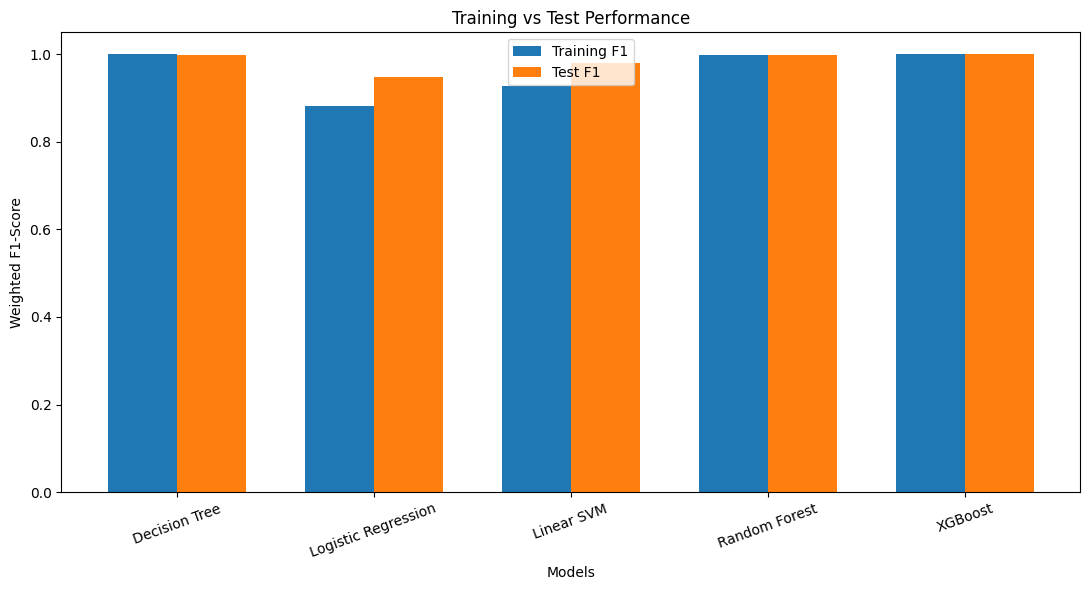

In [48]:
import matplotlib.pyplot as plt
import numpy as np

models_names = generalization_df["Model"]

x = np.arange(len(models_names))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    generalization_df["Training F1"],
    width,
    label="Training F1"
)

plt.bar(
    x + width/2,
    generalization_df["Test F1"],
    width,
    label="Test F1"
)

plt.xlabel("Models")
plt.ylabel("Weighted F1-Score")
plt.title("Training vs Test Performance")
plt.xticks(x, models_names, rotation=20)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
print("=" * 70)
print("OVERFITTING AND GENERALIZATION ANALYSIS")
print("=" * 70)

for _, row in generalization_df.iterrows():

    print(f"\n{row['Model']}")
    print(f"Training F1 : {row['Training F1']:.4f}")
    print(f"Test F1     : {row['Test F1']:.4f}")
    print(f"F1 Gap      : {row['F1 Gap']:.4f}")
    print(f"Status      : {row['Status']}")

OVERFITTING AND GENERALIZATION ANALYSIS

Decision Tree
Training F1 : 0.9996
Test F1     : 0.9994
F1 Gap      : 0.0002
Status      : Good Generalization

Logistic Regression
Training F1 : 0.8810
Test F1     : 0.9480
F1 Gap      : -0.0670
Status      : Good Generalization

Linear SVM
Training F1 : 0.9275
Test F1     : 0.9807
F1 Gap      : -0.0532
Status      : Good Generalization

Random Forest
Training F1 : 0.9994
Test F1     : 0.9993
F1 Gap      : 0.0001
Status      : Good Generalization

XGBoost
Training F1 : 0.9994
Test F1     : 0.9994
F1 Gap      : -0.0000
Status      : Good Generalization


# Step 9: Ensemble Construction

Decision Tree + Random Forest + XGBoost

All three capture nonlinear relationships.
They achieved approximately 99.9% test F1.
They have complementary ensemble strategies:
Decision Tree → single rule-based learner
Random Forest → bagging
XGBoost → boosting
They are the strongest models from your comparison.
They are more appropriate for the proposed ensemble than Logistic Regression/SVM, which are primarily useful as baseline models.


I would not use a simple majority-voting ensemble yet.

Because this is a multiclass intrusion-detection problem with severe class imbalance, first create the ensemble in a way that evaluate whether combining the models actually improves the difficult classes such as Botnet and Web Attack.

In [50]:
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


In [51]:
from scipy.stats import mode
import numpy as np

# Combine predictions
predictions = np.column_stack([
    y_pred_dt,
    y_pred_rf,
    y_pred_xgb
])

# Majority voting
y_pred_ensemble = mode(
    predictions,
    axis=1,
    keepdims=False
).mode

print("Ensemble predictions generated successfully.")
print("Number of predictions:", len(y_pred_ensemble))

Ensemble predictions generated successfully.
Number of predictions: 337842


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)

ensemble_precision = precision_score(
    y_test,
    y_pred_ensemble,
    average='weighted',
    zero_division=0
)

ensemble_recall = recall_score(
    y_test,
    y_pred_ensemble,
    average='weighted',
    zero_division=0
)

ensemble_f1 = f1_score(
    y_test,
    y_pred_ensemble,
    average='weighted',
    zero_division=0
)

print("=" * 60)
print("ENSEMBLE MODEL - MAJORITY VOTING")
print("=" * 60)

print(f"Accuracy : {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall   : {ensemble_recall:.4f}")
print(f"F1-Score : {ensemble_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_ensemble,
        zero_division=0
    )
)

ENSEMBLE MODEL - MAJORITY VOTING
Accuracy : 0.9994
Precision: 0.9996
Recall   : 0.9994
F1-Score : 0.9994

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.98      0.80       391
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00    291425
           4       1.00      1.00      1.00     18164
           5       0.99      0.99      0.99       429

    accuracy                           1.00    337842
   macro avg       0.94      1.00      0.97    337842
weighted avg       1.00      1.00      1.00    337842



In [53]:
ensemble_comparison = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(
            y_test, y_pred_dt,
            average='weighted',
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_dt,
            average='weighted',
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred_dt,
            average='weighted',
            zero_division=0
        )
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(
            y_test, y_pred_rf,
            average='weighted',
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_rf,
            average='weighted',
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred_rf,
            average='weighted',
            zero_division=0
        )
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(
            y_test, y_pred_xgb,
            average='weighted',
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_xgb,
            average='weighted',
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred_xgb,
            average='weighted',
            zero_division=0
        )
    },
    {
        "Model": "Voting Ensemble",
        "Accuracy": ensemble_accuracy,
        "Precision": ensemble_precision,
        "Recall": ensemble_recall,
        "F1-Score": ensemble_f1
    }
])

display(
    ensemble_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.9993,0.9995,0.9993,0.9994
1,Random Forest,0.9992,0.9995,0.9992,0.9993
2,XGBoost,0.9993,0.9995,0.9993,0.9994
3,Voting Ensemble,0.9994,0.9996,0.9994,0.9994


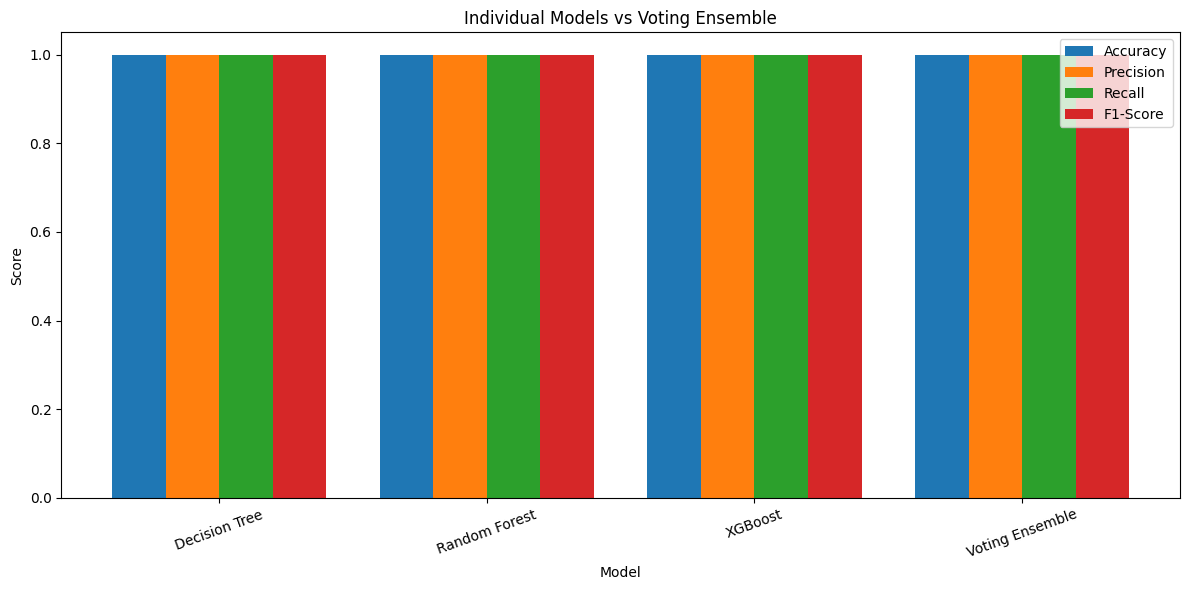

In [54]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(ensemble_comparison))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        ensemble_comparison[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    ensemble_comparison["Model"],
    rotation=20
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Individual Models vs Voting Ensemble")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

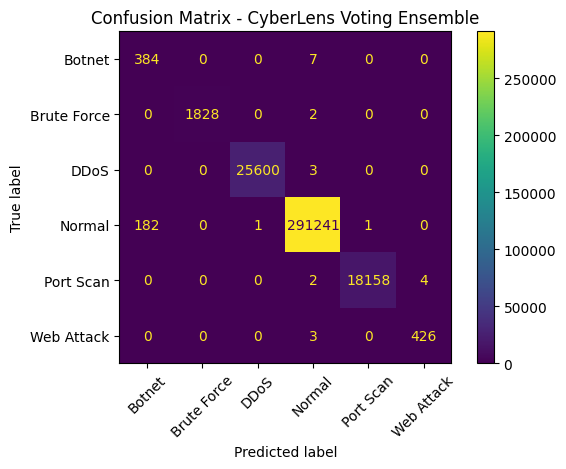

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ensemble,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap=None
)

plt.title("Confusion Matrix - CyberLens Voting Ensemble")
plt.tight_layout()
plt.show()

# Step 10: Detailed Ensable Learning




In [56]:
# Class names for readable evaluation

class_names = [
    "Botnet",
    "Brute Force",
    "DDoS",
    "Normal",
    "Port Scan",
    "Web Attack"
]

print("Class names:", class_names)

Class names: ['Botnet', 'Brute Force', 'DDoS', 'Normal', 'Port Scan', 'Web Attack']


In [57]:
from sklearn.metrics import classification_report

# Detailed classification report
ensemble_report = classification_report(
    y_test,
    y_pred_ensemble,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

ensemble_report_df = pd.DataFrame(ensemble_report).T

display(
    ensemble_report_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)

,precision,recall,f1-score,support
Botnet,0.6784,0.9821,0.8025,391
Brute Force,1.0000,0.9989,0.9995,1830
DDoS,1.0000,0.9999,0.9999,25603
Normal,0.9999,0.9994,0.9997,291425
Port Scan,0.9999,0.9997,0.9998,18164
Web Attack,0.9907,0.9930,0.9919,429
accuracy,0.9994,0.9994,0.9994,1
macro avg,0.9448,0.9955,0.9655,337842
weighted avg,0.9996,0.9994,0.9994,337842


In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score

macro_precision = precision_score(
    y_test, y_pred_ensemble,
    average='macro',
    zero_division=0
)

macro_recall = recall_score(
    y_test, y_pred_ensemble,
    average='macro',
    zero_division=0
)

macro_f1 = f1_score(
    y_test, y_pred_ensemble,
    average='macro',
    zero_division=0
)

weighted_precision = precision_score(
    y_test, y_pred_ensemble,
    average='weighted',
    zero_division=0
)

weighted_recall = recall_score(
    y_test, y_pred_ensemble,
    average='weighted',
    zero_division=0
)

weighted_f1 = f1_score(
    y_test, y_pred_ensemble,
    average='weighted',
    zero_division=0
)

metrics_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Macro Average": [
        macro_precision,
        macro_recall,
        macro_f1
    ],
    "Weighted Average": [
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

display(
    metrics_comparison.style.format({
        "Macro Average": "{:.4f}",
        "Weighted Average": "{:.4f}"
    })
)

,Metric,Macro Average,Weighted Average
0,Precision,0.9448,0.9996
1,Recall,0.9955,0.9994
2,F1-Score,0.9655,0.9994


In [59]:
# Extract only the individual attack/traffic classes

per_class_results = ensemble_report_df.loc[
    class_names,
    ["precision", "recall", "f1-score", "support"]
].copy()

per_class_results.columns = [
    "Precision",
    "Recall",
    "F1-Score",
    "Support"
]

display(
    per_class_results.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Support": "{:.0f}"
    })
)

,Precision,Recall,F1-Score,Support
Botnet,0.6784,0.9821,0.8025,391
Brute Force,1.0000,0.9989,0.9995,1830
DDoS,1.0000,0.9999,0.9999,25603
Normal,0.9999,0.9994,0.9997,291425
Port Scan,0.9999,0.9997,0.9998,18164
Web Attack,0.9907,0.9930,0.9919,429


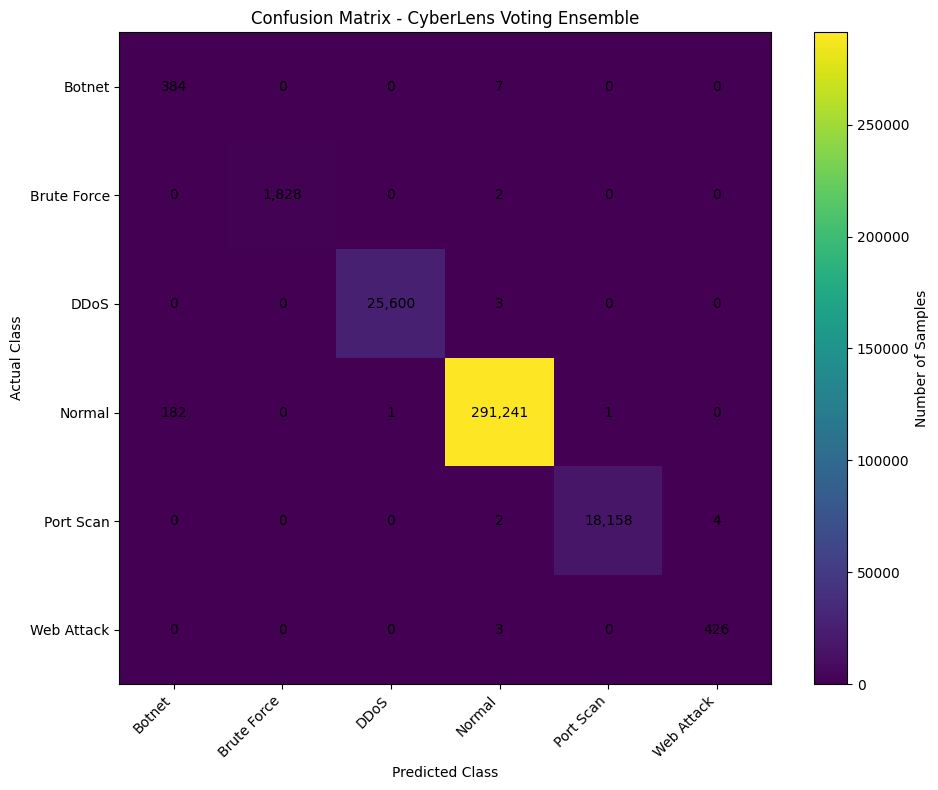

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_ensemble
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix - CyberLens Voting Ensemble")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Samples")
plt.tight_layout()
plt.show()

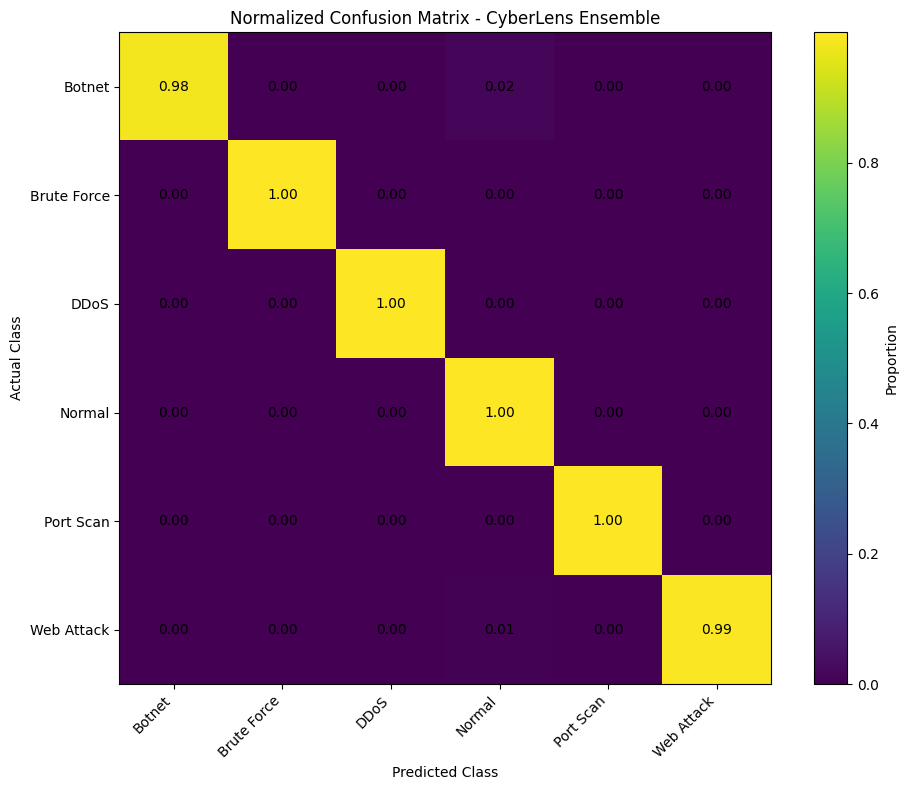

In [61]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred_ensemble,
    normalize='true'
)

plt.figure(figsize=(10, 8))

plt.imshow(cm_normalized)

plt.title("Normalized Confusion Matrix - CyberLens Ensemble")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()

In [62]:
minority_classes = [
    "Botnet",
    "Web Attack"
]

minority_results = per_class_results.loc[
    minority_classes
]

print("Performance on minority attack classes:")
display(
    minority_results.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Support": "{:.0f}"
    })
)

Performance on minority attack classes:


,Precision,Recall,F1-Score,Support
Botnet,0.6784,0.9821,0.8025,391
Web Attack,0.9907,0.9930,0.9919,429


In [63]:
print("=" * 70)
print("CYBERLENS ENSEMBLE - FINAL EVALUATION SUMMARY")
print("=" * 70)

print(f"Accuracy          : {ensemble_accuracy:.4f}")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1        : {weighted_f1:.4f}")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")

print("\nMinority Class Performance:")
print(f"Botnet F1          : {per_class_results.loc['Botnet', 'F1-Score']:.4f}")
print(f"Web Attack F1      : {per_class_results.loc['Web Attack', 'F1-Score']:.4f}")

CYBERLENS ENSEMBLE - FINAL EVALUATION SUMMARY
Accuracy          : 0.9994
Weighted Precision : 0.9996
Weighted Recall    : 0.9994
Weighted F1        : 0.9994
Macro Precision    : 0.9448
Macro Recall       : 0.9955
Macro F1           : 0.9655

Minority Class Performance:
Botnet F1          : 0.8025
Web Attack F1      : 0.9919


# Step 11: Explainable AI (SHAP)

In [64]:
!pip install -q shap

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [65]:
# Select a representative sample from the test set

SHAP_SAMPLE_SIZE = 3000

if len(X_test_scaled) > SHAP_SAMPLE_SIZE:
    rng = np.random.RandomState(42)
    sample_indices = rng.choice(
        len(X_test_scaled),
        size=SHAP_SAMPLE_SIZE,
        replace=False
    )
else:
    sample_indices = np.arange(len(X_test_scaled))

X_shap = X_test_scaled[sample_indices]
y_shap = y_test.iloc[sample_indices] if hasattr(y_test, "iloc") else y_test[sample_indices]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (3000, 67)


In [66]:
# Get feature names

if hasattr(X_test_scaled, "columns"):
    feature_names = X_test_scaled.columns.tolist()
else:
    feature_names = X.columns.tolist()

print("Number of features:", len(feature_names))
print("First 10 features:", feature_names[:10])

Number of features: 67
First 10 features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


In [67]:
# Create SHAP TreeExplainer for XGBoost

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


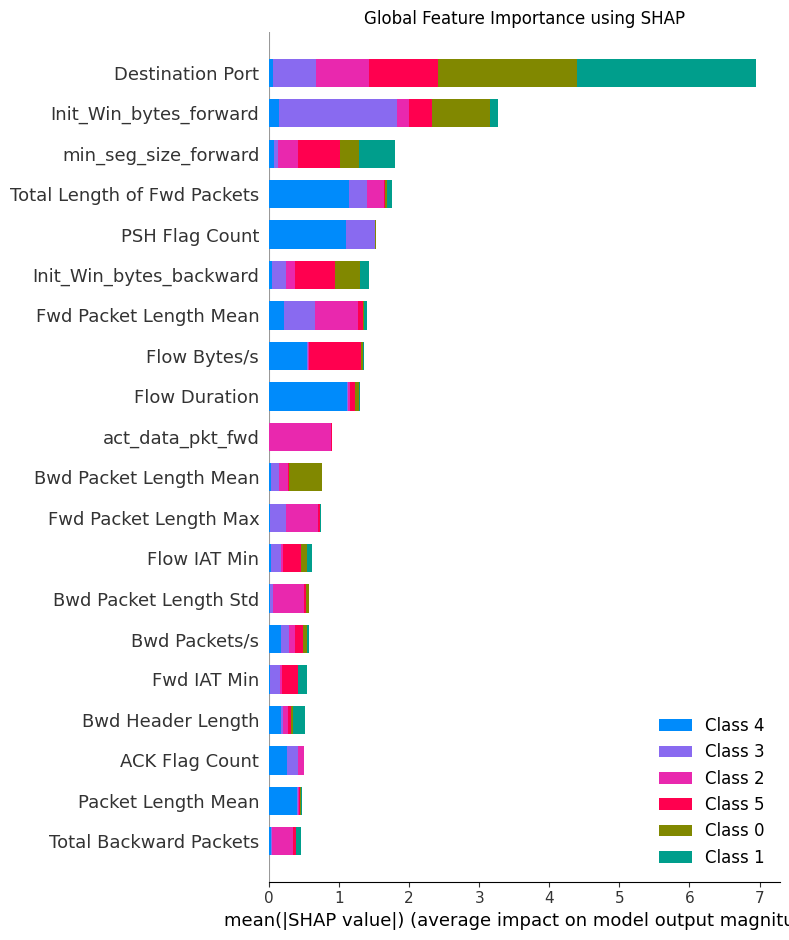

In [68]:
# Global SHAP Feature Importance

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance using SHAP")
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

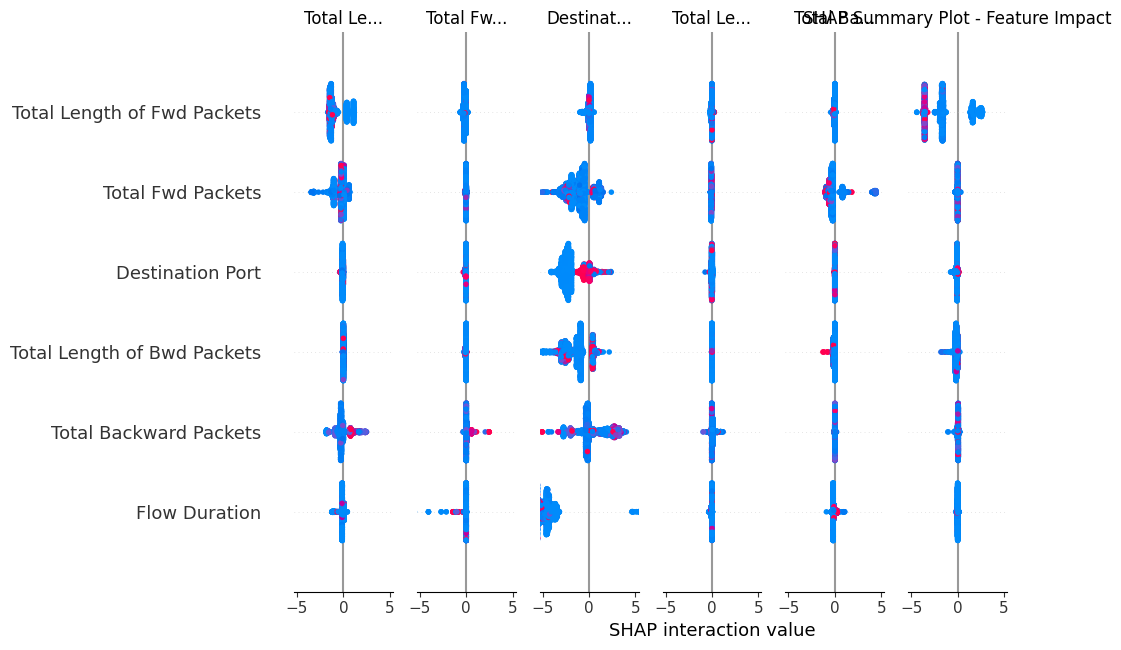

In [69]:
# SHAP Beeswarm Plot - additionally tells us direction and impact

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Feature Impact")
plt.tight_layout()
plt.show()

In [70]:
# Calculate mean absolute SHAP importance

if isinstance(shap_values, list):
    mean_abs_shap = np.mean(
        [
            np.abs(values).mean(axis=0)
            for values in shap_values
        ],
        axis=0
    )
else:
    # Assuming shap_values shape is (num_samples, num_features, num_classes)
    # To get mean importance per feature, average over samples (axis=0) and classes (axis=2)
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP Value|": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean |SHAP Value|",
    ascending=False
).reset_index(drop=True)

display(
    shap_importance.head(20).style.format({
        "Mean |SHAP Value|": "{:.6f}"
    })
)

,Feature,Mean |SHAP Value|
0,Destination Port,1.157356
1,Init_Win_bytes_forward,0.544078
2,min_seg_size_forward,0.299224
3,Total Length of Fwd Packets,0.293642
4,PSH Flag Count,0.255280
5,Init_Win_bytes_backward,0.236718
6,Fwd Packet Length Mean,0.232214
7,Flow Bytes/s,0.226442
8,Flow Duration,0.216205
9,act_data_pkt_fwd,0.150976


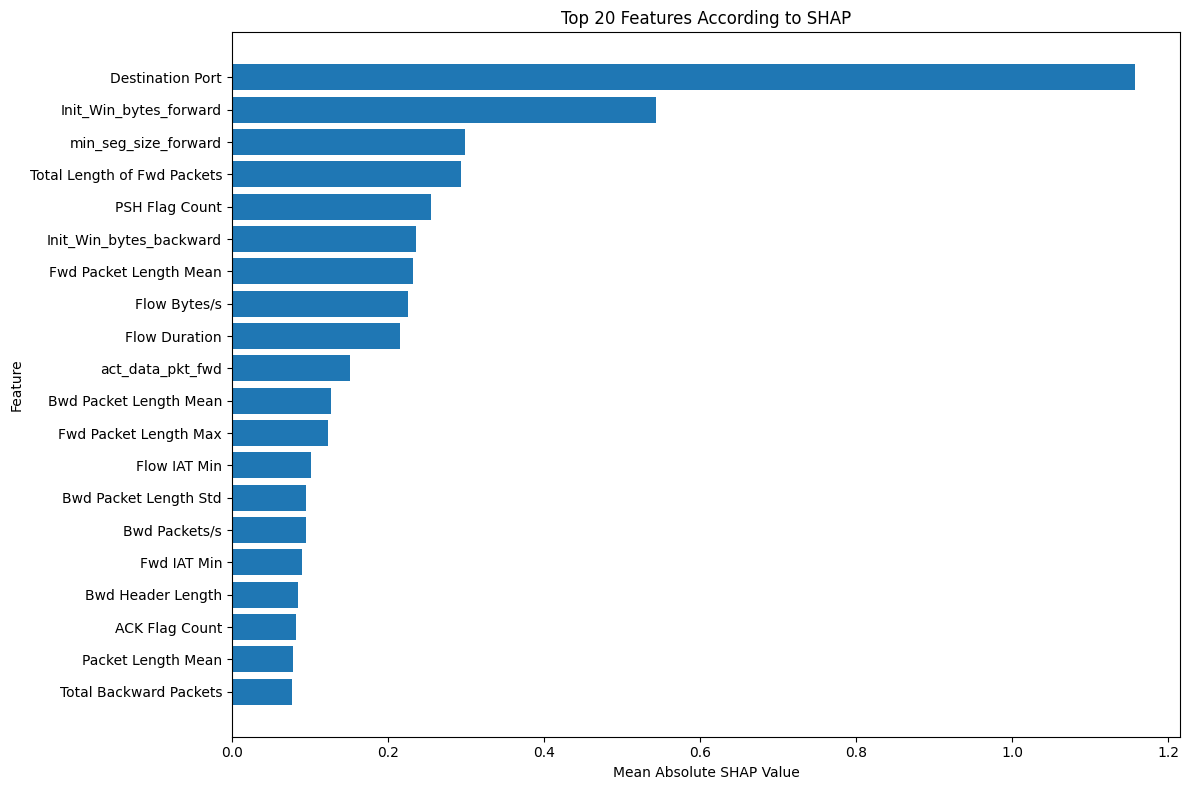

In [71]:
# Top 20 SHAP features

top_features = shap_importance.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean |SHAP Value|"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features According to SHAP")
plt.tight_layout()
plt.show()

In [72]:
# Explain one individual prediction

sample_index = 0

print("Actual class:", class_names[int(y_shap[sample_index])])

prediction = xgb_model.predict(
    X_shap[sample_index:sample_index + 1]
)[0]

print("Predicted class:", class_names[int(prediction)])

Actual class: Normal
Predicted class: Normal


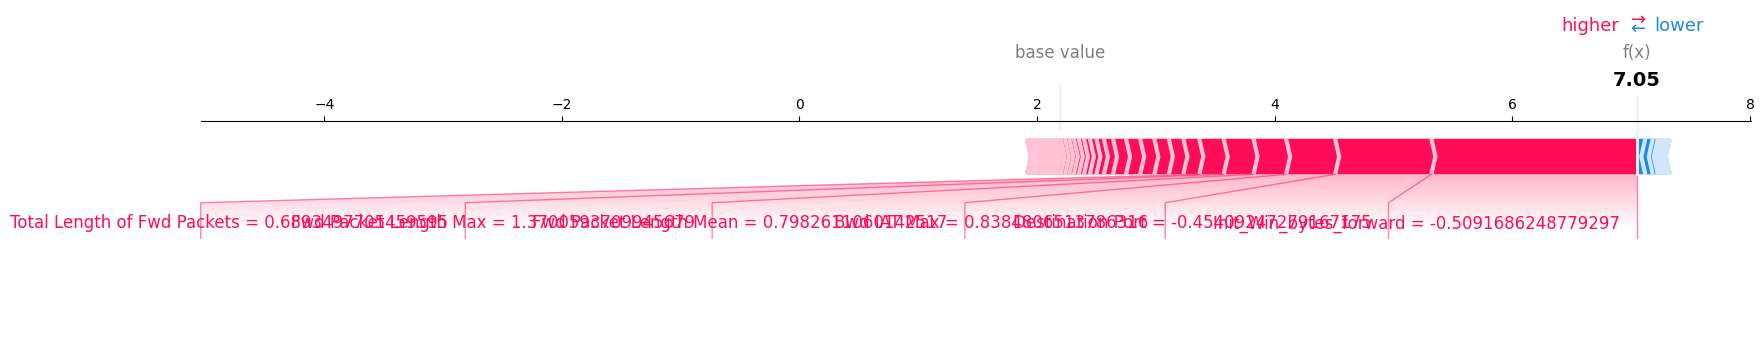

<Figure size 640x480 with 0 Axes>

In [73]:
# Individual SHAP explanation

# Get the predicted class for the current sample
predicted_class_index = int(prediction)

# Get the expected value for the predicted class
expected_value_for_class = explainer.expected_value[predicted_class_index]

# Get the SHAP values for the current sample and predicted class
# shap_values is (num_samples, num_features, num_classes)
shap_values_for_class = shap_values[sample_index, :, predicted_class_index]

shap.force_plot(
    expected_value_for_class,
    shap_values_for_class,
    X_shap[sample_index],
    feature_names=feature_names,
    matplotlib=True
)

plt.tight_layout()
plt.show()

In [74]:
# Step 11: Individual Prediction Explanation

sample_index = 0

# Get SHAP explanation for the selected sample
sample_shap = shap_values[sample_index]

# Get the predicted class
sample_prediction = xgb_model.predict(
    X_shap[sample_index:sample_index + 1]
)[0]

# Get the actual class
sample_actual = (
    y_shap.iloc[sample_index]
    if hasattr(y_shap, "iloc")
    else y_shap[sample_index]
)

print("Actual class   :", class_names[int(sample_actual)])
print("Predicted class:", class_names[int(sample_prediction)])

Actual class   : Normal
Predicted class: Normal


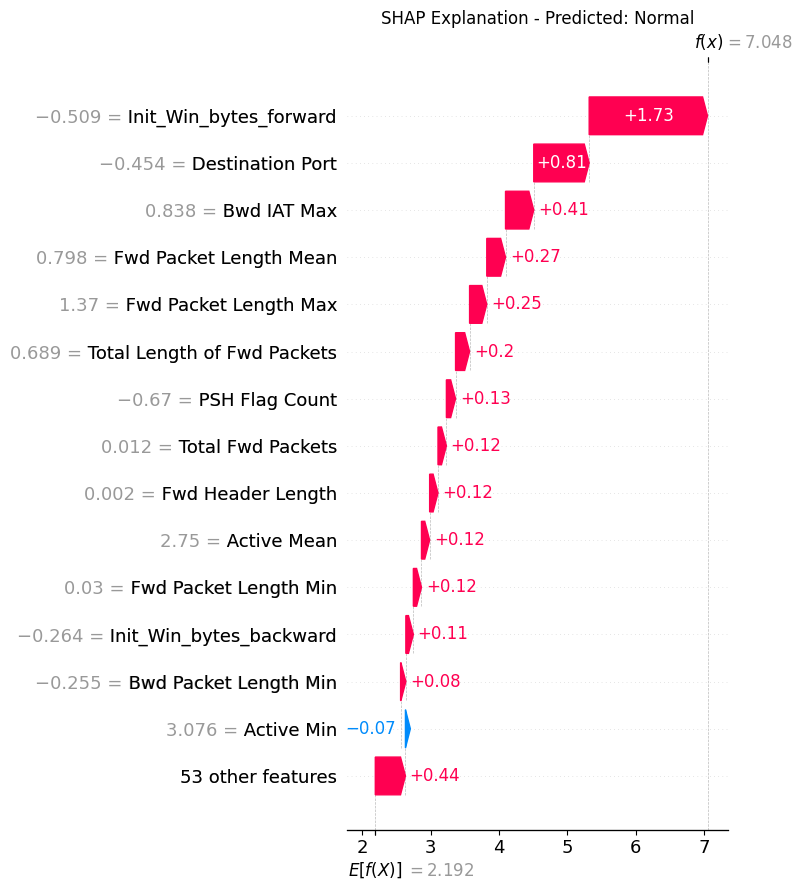

In [75]:
# Create SHAP Explanation object for the individual sample

# Get the predicted class index (already computed in previous cells)
# predicted_class_index = int(prediction)

if isinstance(shap_values, list):
    # This branch is for models that return a list of arrays (e.g., multi-output sklearn models)
    # Assuming shap_values is a list of (num_samples, num_features) arrays, one per class
    sample_values = shap_values[predicted_class_index][sample_index] # Select specific class's SHAP values
    base_value = explainer.expected_value[predicted_class_index]
else:
    # This branch is for models that return a single (num_samples, num_features, num_classes) array
    # Select SHAP values for the specific sample and predicted class
    sample_values = shap_values[sample_index, :, predicted_class_index]

    # Get the base value for the predicted class
    if np.ndim(explainer.expected_value) > 0:
        base_value = explainer.expected_value[predicted_class_index]
    else:
        base_value = explainer.expected_value # For single-output models

sample_explanation = shap.Explanation(
    values=sample_values,
    base_values=base_value,
    data=X_shap[sample_index],
    feature_names=feature_names
)

shap.plots.waterfall(
    sample_explanation,
    max_display=15,
    show=False
)

plt.title(
    f"SHAP Explanation - Predicted: {class_names[int(sample_prediction)]}"
)

plt.tight_layout()
plt.show()

# Step 12: Attack-Specific Explainability

In [77]:
# Step 12: Attack-Specific SHAP Analysis

class_shap_importance = {}

for class_index, class_name in enumerate(class_names):

    # For multiclass XGBoost, obtain SHAP values for this class
    class_values = shap_values[:, :, class_index]

    mean_abs_values = np.abs(class_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean |SHAP Value|": mean_abs_values
    })

    importance_df = importance_df.sort_values(
        by="Mean |SHAP Value|",
        ascending=False
    ).reset_index(drop=True)

    class_shap_importance[class_name] = importance_df

print("Class-specific SHAP analysis completed.")

Class-specific SHAP analysis completed.


In [78]:
for class_name in class_names:

    print("\n" + "=" * 60)
    print(f"TOP FEATURES FOR: {class_name}")
    print("=" * 60)

    display(
        class_shap_importance[class_name].head(10).style.format({
            "Mean |SHAP Value|": "{:.6f}"
        })
    )


TOP FEATURES FOR: Botnet


,Feature,Mean |SHAP Value|
0,Destination Port,1.993588
1,Init_Win_bytes_forward,0.833092
2,Bwd Packet Length Mean,0.476211
3,Init_Win_bytes_backward,0.353261
4,min_seg_size_forward,0.279871
5,Bwd Packet Length Max,0.202593
6,Bwd IAT Std,0.112911
7,Flow IAT Min,0.083022
8,Fwd Header Length,0.075047
9,Avg Bwd Segment Size,0.074150



TOP FEATURES FOR: Brute Force


,Feature,Mean |SHAP Value|
0,Destination Port,2.542583
1,min_seg_size_forward,0.506331
2,Bwd Header Length,0.175728
3,Bwd Packet Length Min,0.158240
4,Fwd IAT Mean,0.153535
5,Bwd IAT Mean,0.142820
6,Init_Win_bytes_backward,0.119756
7,Fwd IAT Min,0.119242
8,Fwd PSH Flags,0.108436
9,Init_Win_bytes_forward,0.105162



TOP FEATURES FOR: DDoS


...

,Feature,Mean |SHAP Value|
0,Init_Win_bytes_forward,1.682327
1,Destination Port,0.616215
2,Fwd Packet Length Mean,0.446984
3,PSH Flag Count,0.415722
4,Total Length of Fwd Packets,0.253460
5,Fwd Packet Length Max,0.227170
6,Init_Win_bytes_backward,0.199815
7,ACK Flag Count,0.153436
8,Fwd IAT Min,0.151367
9,Flow IAT Min,0.142990



TOP FEATURES FOR: Port Scan


,Feature,Mean |SHAP Value|
0,Total Length of Fwd Packets,1.143142
1,Flow Duration,1.106575
2,PSH Flag Count,1.101820
3,Flow Bytes/s,0.540120
4,Packet Length Mean,0.400746
5,Subflow Fwd Bytes,0.264528
6,ACK Flag Count,0.260200
7,Fwd Packet Length Mean,0.208504
8,Bwd Header Length,0.176226
9,Bwd Packets/s,0.170204



TOP FEATURES FOR: Web Attack


,Feature,Mean |SHAP Value|
0,Destination Port,0.987439
1,Flow Bytes/s,0.747846
2,min_seg_size_forward,0.594799
3,Init_Win_bytes_backward,0.576158
4,Init_Win_bytes_forward,0.323591
5,Flow IAT Min,0.248747
6,Fwd IAT Min,0.216869
7,Fwd Packet Length Std,0.188579
8,Max Packet Length,0.184153
9,Flow Packets/s,0.172545


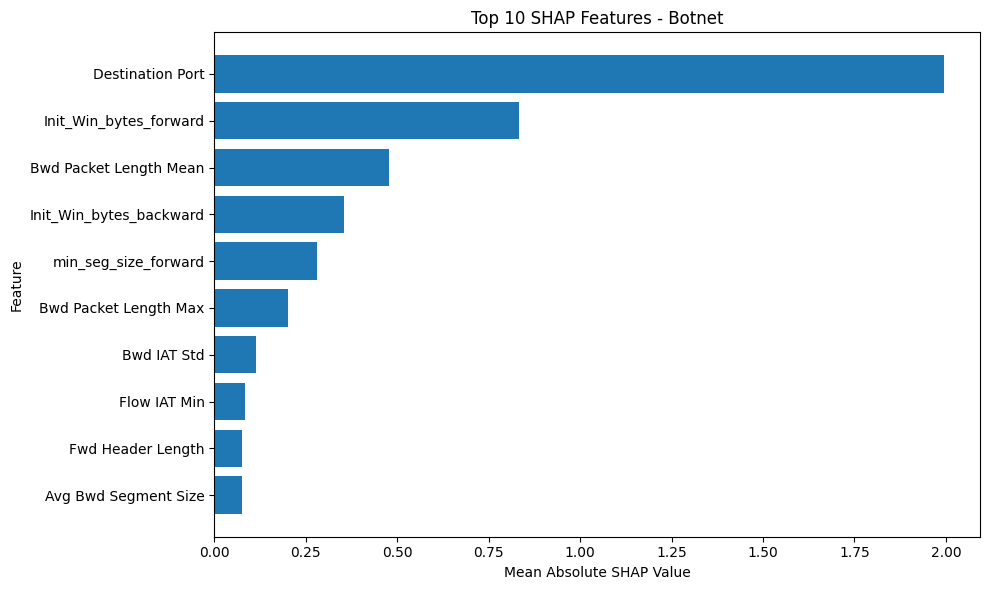

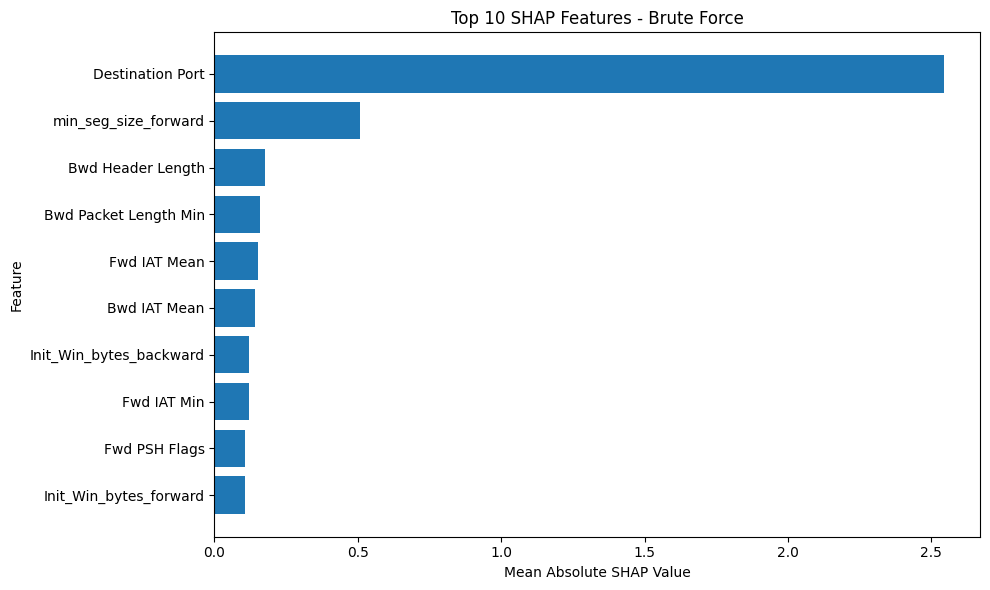

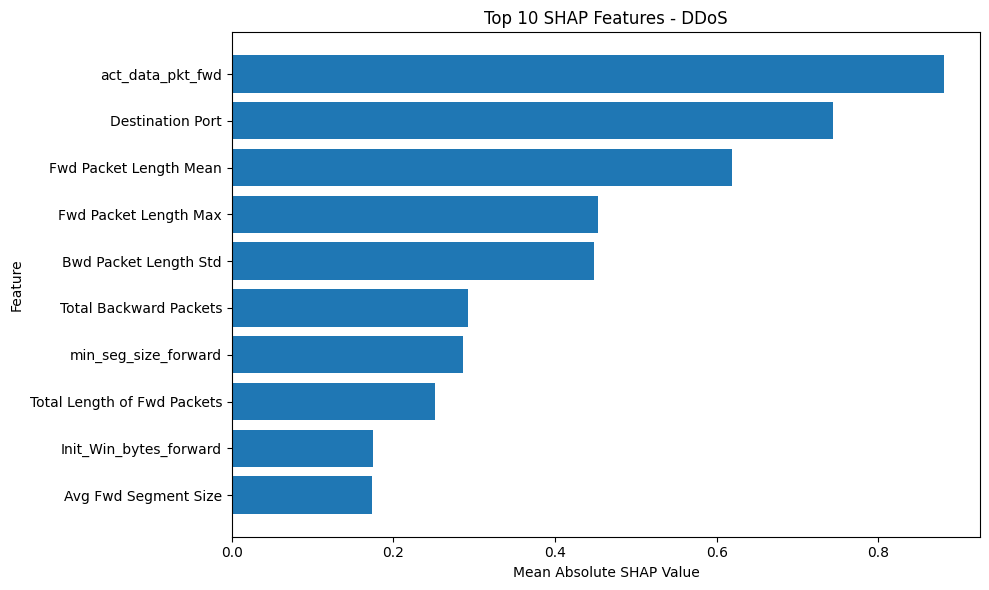

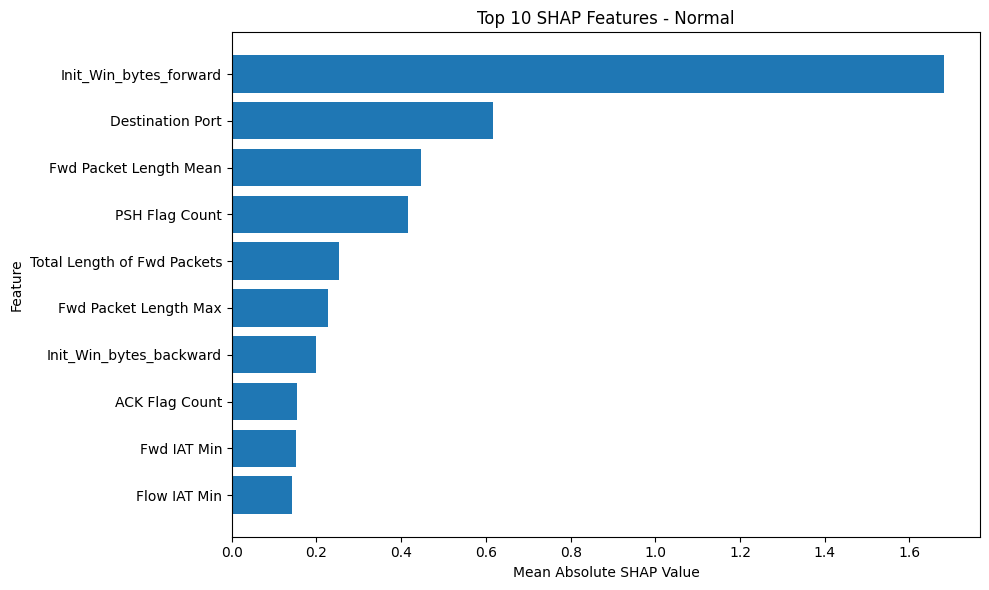

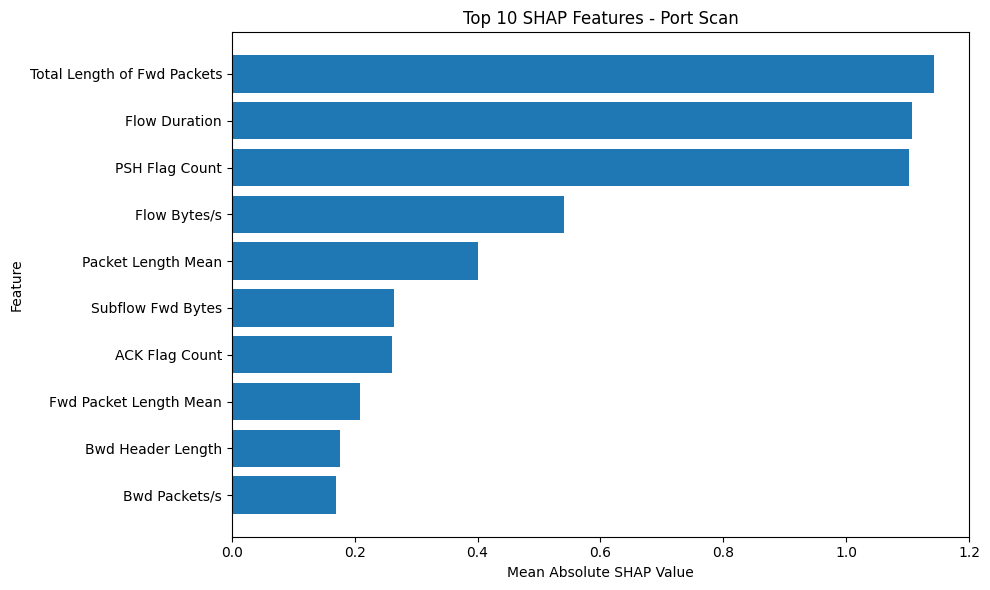

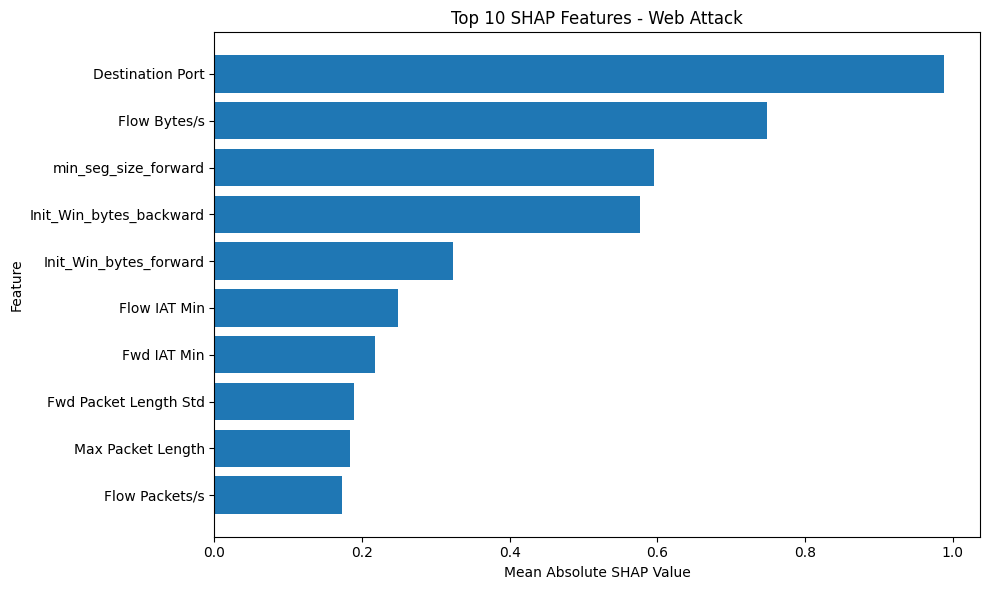

In [79]:
for class_name in class_names:

    top_features = class_shap_importance[class_name].head(10)

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_features["Feature"][::-1],
        top_features["Mean |SHAP Value|"][::-1]
    )

    plt.xlabel("Mean Absolute SHAP Value")
    plt.ylabel("Feature")
    plt.title(
        f"Top 10 SHAP Features - {class_name}"
    )

    plt.tight_layout()
    plt.show()

In [80]:
# Create consolidated attack-specific SHAP table

top_n = 10

attack_shap_summary = []

for class_name in class_names:

    top_features = class_shap_importance[class_name].head(top_n)

    for rank, (_, row) in enumerate(top_features.iterrows(), start=1):

        attack_shap_summary.append({
            "Class": class_name,
            "Rank": rank,
            "Feature": row["Feature"],
            "Mean |SHAP Value|": row["Mean |SHAP Value|"]
        })

attack_shap_summary_df = pd.DataFrame(
    attack_shap_summary
)

display(
    attack_shap_summary_df.style.format({
        "Mean |SHAP Value|": "{:.6f}"
    })
)

,Class,Rank,Feature,Mean |SHAP Value|
0,Botnet,1,Destination Port,1.993588
1,Botnet,2,Init_Win_bytes_forward,0.833092
2,Botnet,3,Bwd Packet Length Mean,0.476211
3,Botnet,4,Init_Win_bytes_backward,0.353261
4,Botnet,5,min_seg_size_forward,0.279871
5,Botnet,6,Bwd Packet Length Max,0.202593
6,Botnet,7,Bwd IAT Std,0.112911
7,Botnet,8,Flow IAT Min,0.083022
8,Botnet,9,Fwd Header Length,0.075047
9,Botnet,10,Avg Bwd Segment Size,0.074150


In [81]:
# Compare the top 5 features for each class

top_5_features = {}

for class_name in class_names:

    top_5_features[class_name] = (
        class_shap_importance[class_name]
        .head(5)["Feature"]
        .tolist()
    )

for class_name, features in top_5_features.items():

    print(f"\n{class_name}:")

    for rank, feature in enumerate(features, start=1):
        print(f"  {rank}. {feature}")


Botnet:
  1. Destination Port
  2. Init_Win_bytes_forward
  3. Bwd Packet Length Mean
  4. Init_Win_bytes_backward
  5. min_seg_size_forward

Brute Force:
  1. Destination Port
  2. min_seg_size_forward
  3. Bwd Header Length
  4. Bwd Packet Length Min
  5. Fwd IAT Mean

DDoS:
  1. act_data_pkt_fwd
  2. Destination Port
  3. Fwd Packet Length Mean
  4. Fwd Packet Length Max
  5. Bwd Packet Length Std

Normal:
  1. Init_Win_bytes_forward
  2. Destination Port
  3. Fwd Packet Length Mean
  4. PSH Flag Count
  5. Total Length of Fwd Packets

Port Scan:
  1. Total Length of Fwd Packets
  2. Flow Duration
  3. PSH Flag Count
  4. Flow Bytes/s
  5. Packet Length Mean

Web Attack:
  1. Destination Port
  2. Flow Bytes/s
  3. min_seg_size_forward
  4. Init_Win_bytes_backward
  5. Init_Win_bytes_forward


# Step 13: Build the CyberLens Prediction + Explanation Pipeline

In [82]:
# Step 13: CyberLens Prediction and Explanation Pipeline

def predict_with_cyberlens(sample):

    # Convert sample to DataFrame if necessary
    if isinstance(sample, pd.Series):
        sample = sample.to_frame().T
    elif isinstance(sample, np.ndarray):
        sample = pd.DataFrame(sample, columns=feature_names)

    # Apply the same scaler used during training
    sample_scaled = scaler.transform(sample)

    # Individual model predictions
    dt_prediction = dt_model.predict(sample_scaled)[0]
    rf_prediction = rf_model.predict(sample_scaled)[0]
    xgb_prediction = xgb_model.predict(sample_scaled)[0]

    # Majority voting
    model_predictions = np.array([
        dt_prediction,
        rf_prediction,
        xgb_prediction
    ])

    ensemble_prediction = mode(
        model_predictions,
        keepdims=False
    ).mode

    predicted_class = class_names[int(ensemble_prediction)]

    return {
        "Decision Tree": class_names[int(dt_prediction)],
        "Random Forest": class_names[int(rf_prediction)],
        "XGBoost": class_names[int(xgb_prediction)],
        "Ensemble Prediction": predicted_class
    }

In [83]:
# Select one sample from the original test data

sample = X_test.iloc[0]

prediction_result = predict_with_cyberlens(sample)

print("=" * 60)
print("CYBERLENS PREDICTION")
print("=" * 60)

for key, value in prediction_result.items():
    print(f"{key:<22}: {value}")

CYBERLENS PREDICTION
Decision Tree         : Normal
Random Forest         : Normal
XGBoost               : Normal
Ensemble Prediction   : Normal


In [84]:
def get_xgb_confidence(sample):

    if isinstance(sample, pd.Series):
        sample = sample.to_frame().T
    elif isinstance(sample, np.ndarray):
        sample = pd.DataFrame(sample, columns=feature_names)

    sample_scaled = scaler.transform(sample)

    probabilities = xgb_model.predict_proba(sample_scaled)[0]

    predicted_class_index = np.argmax(probabilities)

    predicted_class = class_names[predicted_class_index]

    confidence = probabilities[predicted_class_index]

    return predicted_class, confidence, probabilities

In [85]:
predicted_class, confidence, probabilities = get_xgb_confidence(sample)

print("=" * 60)
print("XGBOOST PREDICTION CONFIDENCE")
print("=" * 60)

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.4f}")
print(f"Confidence (%)  : {confidence * 100:.2f}%")

XGBOOST PREDICTION CONFIDENCE
Predicted Class : Normal
Confidence      : 1.0000
Confidence (%)  : 100.00%


In [86]:
probability_df = pd.DataFrame({
    "Class": class_names,
    "Probability": probabilities
})

probability_df = probability_df.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

display(
    probability_df.style.format({
        "Probability": "{:.4f}"
    })
)

,Class,Probability
0,Normal,1.0000
1,DDoS,0.0000
2,Brute Force,0.0000
3,Botnet,0.0000
4,Port Scan,0.0000
5,Web Attack,0.0000


In [87]:
def explain_prediction(sample):

    if isinstance(sample, pd.Series):
        sample = sample.to_frame().T
    elif isinstance(sample, np.ndarray):
        sample = pd.DataFrame(sample, columns=feature_names)

    sample_scaled = scaler.transform(sample)

    # Prediction
    prediction = xgb_model.predict(sample_scaled)[0]

    probabilities = xgb_model.predict_proba(sample_scaled)[0]

    confidence = probabilities[prediction]

    # SHAP values
    sample_shap_values = explainer.shap_values(sample_scaled)

    if isinstance(sample_shap_values, list):
        class_shap = sample_shap_values[prediction][0]
    else:
        class_shap = sample_shap_values[0, :, prediction]

    explanation_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP Value": class_shap,
        "Absolute SHAP": np.abs(class_shap)
    })

    explanation_df = explanation_df.sort_values(
        "Absolute SHAP",
        ascending=False
    ).reset_index(drop=True)

    return (
        class_names[int(prediction)],
        confidence,
        explanation_df
    )

In [88]:
predicted_class, confidence, explanation_df = explain_prediction(sample)

print("=" * 70)
print("CYBERLENS - PREDICTION + EXPLANATION")
print("=" * 70)

print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence * 100:.2f}%")

print("\nTop contributing features:")

display(
    explanation_df.head(10).style.format({
        "SHAP Value": "{:.6f}",
        "Absolute SHAP": "{:.6f}"
    })
)

CYBERLENS - PREDICTION + EXPLANATION
Prediction : Normal
Confidence : 100.00%

Top contributing features:


,Feature,SHAP Value,Absolute SHAP
0,Init_Win_bytes_forward,3.342709,3.342709
1,Fwd Packet Length Mean,0.539520,0.539520
2,PSH Flag Count,0.277773,0.277773
3,Fwd Packet Length Max,0.215362,0.215362
4,Fwd Packet Length Min,0.201559,0.201559
5,Init_Win_bytes_backward,0.136329,0.136329
6,Bwd Packet Length Min,0.133952,0.133952
7,Total Length of Fwd Packets,-0.128048,0.128048
8,Fwd Header Length,0.126141,0.126141
9,ACK Flag Count,-0.113935,0.113935


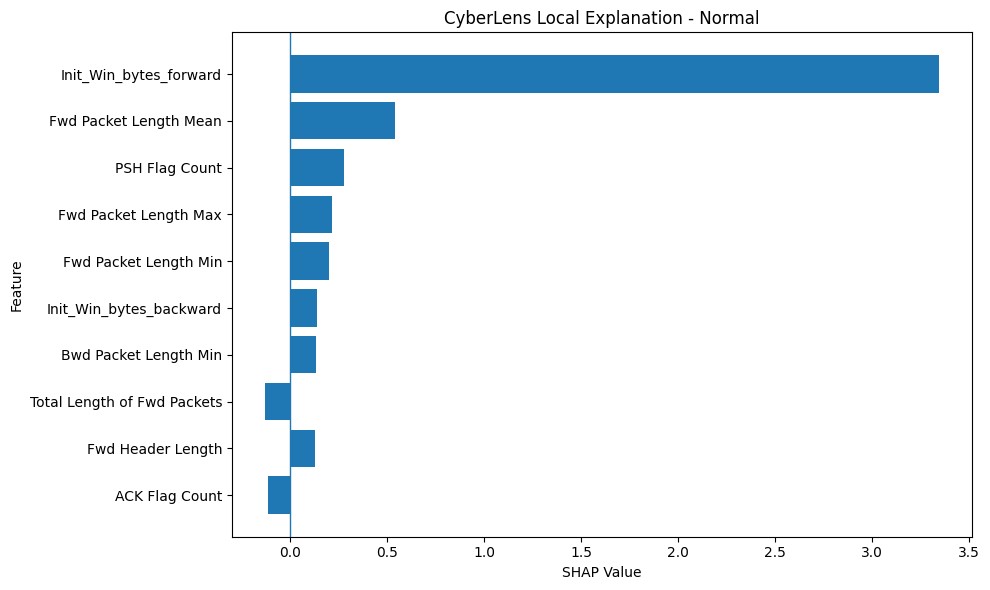

In [89]:
top_explanations = explanation_df.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_explanations["Feature"][::-1],
    top_explanations["SHAP Value"][::-1]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title(
    f"CyberLens Local Explanation - {predicted_class}"
)

plt.tight_layout()
plt.show()

# Step 14: Final Model Evaluation & Comparison

In [90]:
# Step 14: Final Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Voting Ensemble": y_pred_ensemble
}

final_results = []

for model_name, predictions in final_models.items():

    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),

        "Macro Precision": precision_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Weighted Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Weighted Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

final_results_df = pd.DataFrame(final_results)

display(
    final_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted Recall": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Decision Tree,0.9993,0.9422,0.9922,0.9632,0.9995,0.9993,0.9994
1,Random Forest,0.9992,0.9364,0.9920,0.9584,0.9995,0.9992,0.9993
2,XGBoost,0.9993,0.9395,0.9972,0.9626,0.9995,0.9993,0.9994
3,Voting Ensemble,0.9994,0.9448,0.9955,0.9655,0.9996,0.9994,0.9994


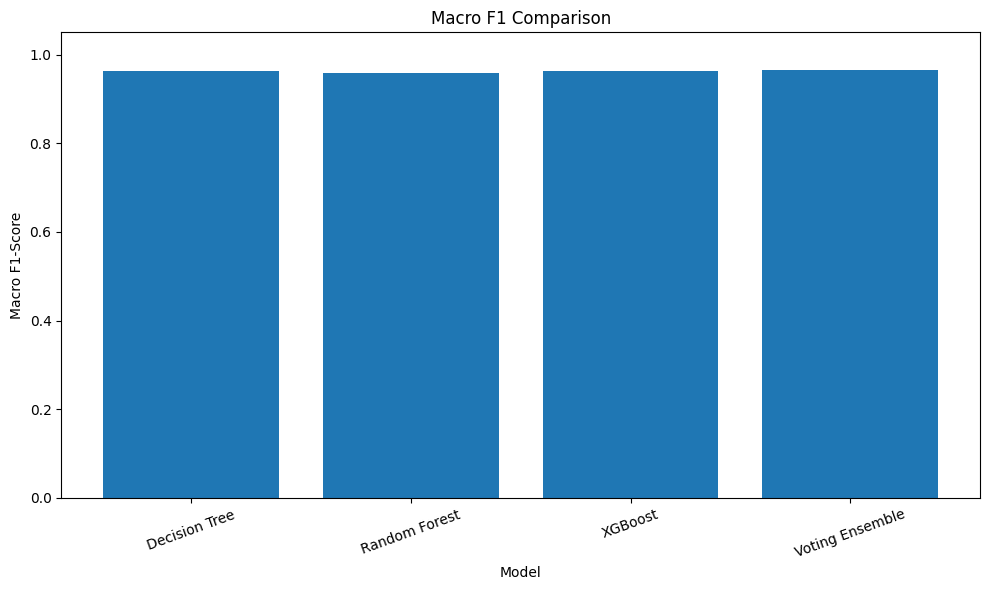

In [91]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results_df["Model"],
    final_results_df["Macro F1"]
)

plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.title("Macro F1 Comparison")
plt.ylim(0, 1.05)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [92]:
# Per-class F1 comparison

per_class_f1 = pd.DataFrame(index=class_names)

for model_name, predictions in final_models.items():

    report = classification_report(
        y_test,
        predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    per_class_f1[model_name] = [
        report[class_name]["f1-score"]
        for class_name in class_names
    ]

display(
    per_class_f1.style.format("{:.4f}")
)

,Decision Tree,Random Forest,XGBoost,Voting Ensemble
Botnet,0.8004,0.7672,0.7846,0.8025
Brute Force,0.9984,0.9992,0.9997,0.9995
DDoS,0.9997,0.9998,0.9999,0.9999
Normal,0.9996,0.9996,0.9996,0.9997
Port Scan,0.9996,0.9998,0.9998,0.9998
Web Attack,0.9815,0.9849,0.9919,0.9919


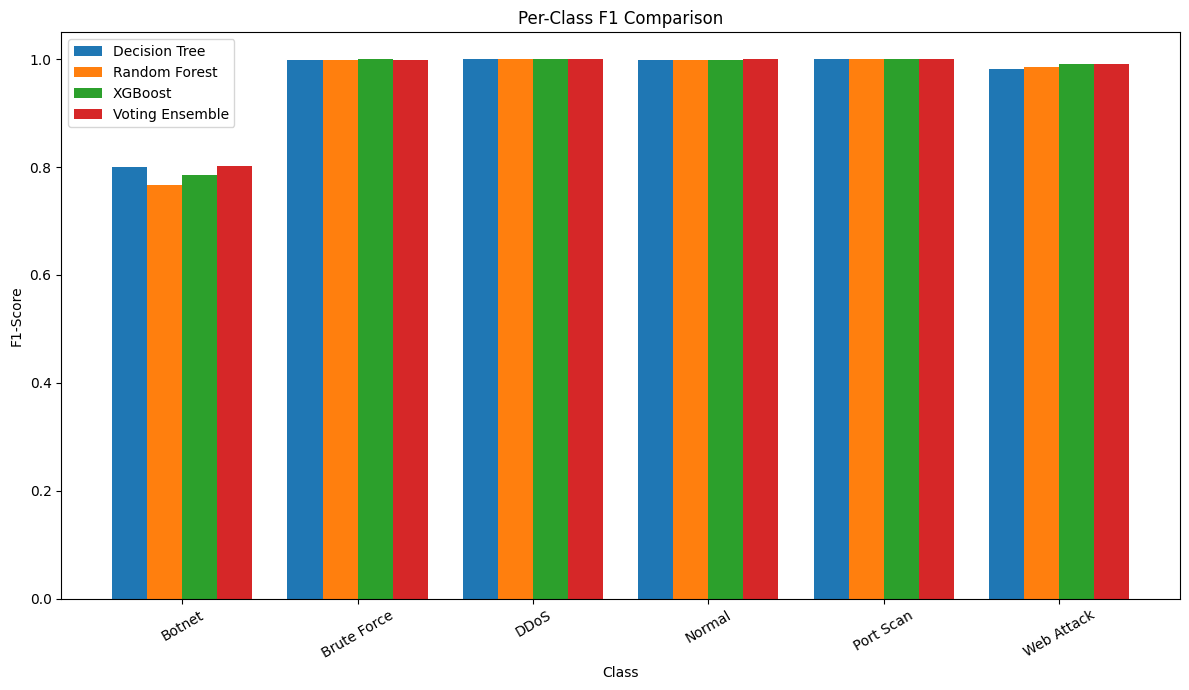

In [93]:
plt.figure(figsize=(12, 7))

x = np.arange(len(class_names))
width = 0.2

for i, model_name in enumerate(final_models.keys()):

    plt.bar(
        x + (i - 1.5) * width,
        per_class_f1[model_name],
        width,
        label=model_name
    )

plt.xlabel("Class")
plt.ylabel("F1-Score")
plt.title("Per-Class F1 Comparison")
plt.xticks(
    x,
    class_names,
    rotation=30
)

plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [94]:
minority_classes = ["Botnet", "Web Attack"]

minority_comparison = per_class_f1.loc[
    minority_classes
]

display(
    minority_comparison.style.format("{:.4f}")
)

,Decision Tree,Random Forest,XGBoost,Voting Ensemble
Botnet,0.8004,0.7672,0.7846,0.8025
Web Attack,0.9815,0.9849,0.9919,0.9919


In [95]:
# Compare ensemble against XGBoost

xgb_f1 = final_results_df.loc[
    final_results_df["Model"] == "XGBoost",
    "Weighted F1"
].iloc[0]

ensemble_f1 = final_results_df.loc[
    final_results_df["Model"] == "Voting Ensemble",
    "Weighted F1"
].iloc[0]

f1_improvement = ensemble_f1 - xgb_f1

print(f"XGBoost Weighted F1      : {xgb_f1:.6f}")
print(f"Ensemble Weighted F1     : {ensemble_f1:.6f}")
print(f"Improvement              : {f1_improvement:.6f}")

XGBoost Weighted F1      : 0.999389
Ensemble Weighted F1     : 0.999444
Improvement              : 0.000055


In [96]:
xgb_accuracy = final_results_df.loc[
    final_results_df["Model"] == "XGBoost",
    "Accuracy"
].iloc[0]

ensemble_accuracy_final = final_results_df.loc[
    final_results_df["Model"] == "Voting Ensemble",
    "Accuracy"
].iloc[0]

accuracy_improvement = ensemble_accuracy_final - xgb_accuracy

print(f"XGBoost Accuracy         : {xgb_accuracy:.6f}")
print(f"Ensemble Accuracy        : {ensemble_accuracy_final:.6f}")
print(f"Improvement              : {accuracy_improvement:.6f}")

XGBoost Accuracy         : 0.999325
Ensemble Accuracy        : 0.999393
Improvement              : 0.000068


In [97]:
best_model_row = final_results_df.loc[
    final_results_df["Macro F1"].idxmax()
]

print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)

print(f"Best Model based on Macro F1 : {best_model_row['Model']}")
print(f"Macro F1                    : {best_model_row['Macro F1']:.4f}")
print(f"Macro Precision             : {best_model_row['Macro Precision']:.4f}")
print(f"Macro Recall                : {best_model_row['Macro Recall']:.4f}")
print(f"Weighted F1                 : {best_model_row['Weighted F1']:.4f}")

FINAL MODEL SELECTION
Best Model based on Macro F1 : Voting Ensemble
Macro F1                    : 0.9655
Macro Precision             : 0.9448
Macro Recall                : 0.9955
Weighted F1                 : 0.9994


# Step 15: Robustness and Cross-Validation Analysis

In [98]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd

# Use a manageable subset for cross-validation
CV_SAMPLE_SIZE = 50000

if len(X_train_scaled) > CV_SAMPLE_SIZE:

    rng = np.random.RandomState(42)

    cv_indices = rng.choice(
        len(X_train_scaled),
        size=CV_SAMPLE_SIZE,
        replace=False
    )

    X_cv = X_train_scaled[cv_indices]
    y_cv = (
        y_train.iloc[cv_indices]
        if hasattr(y_train, "iloc")
        else y_train[cv_indices]
    )

else:
    X_cv = X_train_scaled
    y_cv = y_train

print("Cross-validation dataset:")
print("X shape:", X_cv.shape)
print("y shape:", y_cv.shape)

Cross-validation dataset:
X shape: (50000, 67)
y shape: (50000,)


In [99]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Stratified 3-Fold Cross-Validation configured.")

Stratified 3-Fold Cross-Validation configured.


In [100]:
# Step 15: Robustness Validation
# 3-Fold Stratified Validation of the CyberLens Ensemble

from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import mode
import numpy as np
import pandas as pd
import time

cv_results = []

# Use the models' current hyperparameters as templates
dt_template = clone(dt_model)
rf_template = clone(rf_model)
xgb_template = clone(xgb_model)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cv, y_cv), start=1
):

    print("=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    X_fold_train = X_cv[train_idx]
    X_fold_val = X_cv[val_idx]

    y_fold_train = (
        y_cv.iloc[train_idx]
        if hasattr(y_cv, "iloc")
        else y_cv[train_idx]
    )

    y_fold_val = (
        y_cv.iloc[val_idx]
        if hasattr(y_cv, "iloc")
        else y_cv[val_idx]
    )

    # Train models
    start_time = time.time()

    dt_fold = clone(dt_template)
    rf_fold = clone(rf_template)
    xgb_fold = clone(xgb_template)

    dt_fold.fit(X_fold_train, y_fold_train)

    print("Decision Tree trained.")

    rf_fold.fit(X_fold_train, y_fold_train)

    print("Random Forest trained.")

    xgb_fold.fit(X_fold_train, y_fold_train)

    print("XGBoost trained.")

    training_time = time.time() - start_time

    # Predictions
    dt_pred = dt_fold.predict(X_fold_val)
    rf_pred = rf_fold.predict(X_fold_val)
    xgb_pred = xgb_fold.predict(X_fold_val)

    # Majority voting
    fold_predictions = np.column_stack([
        dt_pred,
        rf_pred,
        xgb_pred
    ])

    ensemble_pred = mode(
        fold_predictions,
        axis=1,
        keepdims=False
    ).mode

    # Metrics
    fold_accuracy = accuracy_score(
        y_fold_val,
        ensemble_pred
    )

    fold_macro_f1 = f1_score(
        y_fold_val,
        ensemble_pred,
        average="macro",
        zero_division=0
    )

    fold_weighted_f1 = f1_score(
        y_fold_val,
        ensemble_pred,
        average="weighted",
        zero_division=0
    )

    cv_results.append({
        "Fold": fold,
        "Accuracy": fold_accuracy,
        "Macro F1": fold_macro_f1,
        "Weighted F1": fold_weighted_f1,
        "Training Time (sec)": training_time
    })

    print(f"Accuracy     : {fold_accuracy:.4f}")
    print(f"Macro F1     : {fold_macro_f1:.4f}")
    print(f"Weighted F1  : {fold_weighted_f1:.4f}")
    print(f"Training Time: {training_time:.2f} sec")

FOLD 1
Decision Tree trained.
Random Forest trained.
XGBoost trained.
Accuracy     : 0.9992
Macro F1     : 0.9467
Weighted F1  : 0.9992
Training Time: 31.26 sec
FOLD 2
Decision Tree trained.
Random Forest trained.
XGBoost trained.
Accuracy     : 0.9987
Macro F1     : 0.8853
Weighted F1  : 0.9985
Training Time: 23.09 sec
FOLD 3
Decision Tree trained.
Random Forest trained.
XGBoost trained.
Accuracy     : 0.9989
Macro F1     : 0.9346
Weighted F1  : 0.9989
Training Time: 16.80 sec


In [101]:
cv_results_df = pd.DataFrame(cv_results)

print("=" * 70)
print("CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Training Time (sec)": "{:.2f}"
    })
)

CROSS-VALIDATION RESULTS


,Fold,Accuracy,Macro F1,Weighted F1,Training Time (sec)
0,1,0.9992,0.9467,0.9992,31.26
1,2,0.9987,0.8853,0.9985,23.09
2,3,0.9989,0.9346,0.9989,16.80


In [102]:
cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ],

    "Mean": [
        cv_results_df["Accuracy"].mean(),
        cv_results_df["Macro F1"].mean(),
        cv_results_df["Weighted F1"].mean()
    ],

    "Std Dev": [
        cv_results_df["Accuracy"].std(),
        cv_results_df["Macro F1"].std(),
        cv_results_df["Weighted F1"].std()
    ]
})

display(
    cv_summary.style.format({
        "Mean": "{:.4f}",
        "Std Dev": "{:.4f}"
    })
)

,Metric,Mean,Std Dev
0,Accuracy,0.9989,0.0003
1,Macro F1,0.9222,0.0325
2,Weighted F1,0.9989,0.0004


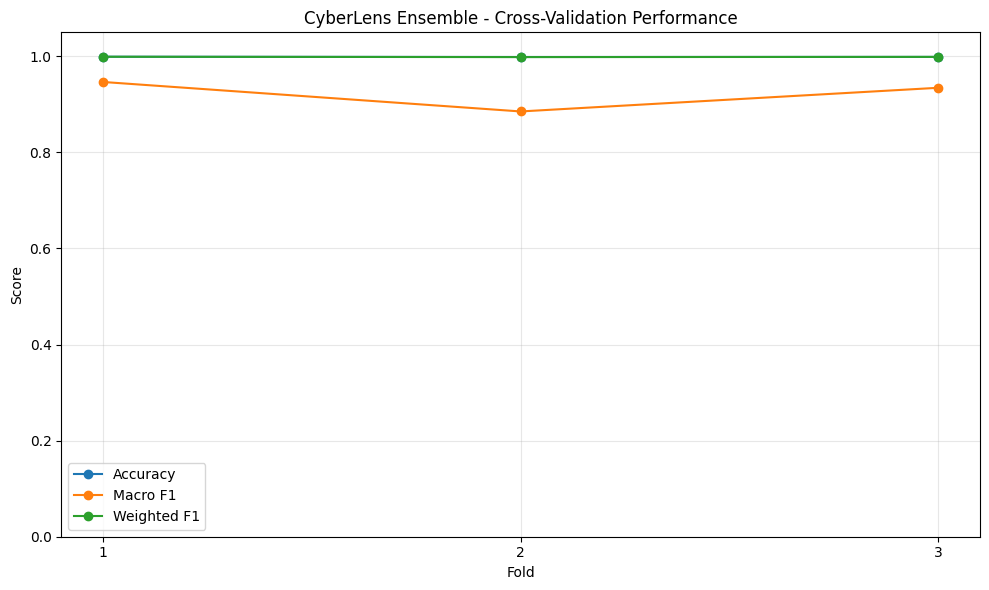

In [103]:
plt.figure(figsize=(10, 6))

plt.plot(
    cv_results_df["Fold"],
    cv_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    cv_results_df["Fold"],
    cv_results_df["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    cv_results_df["Fold"],
    cv_results_df["Weighted F1"],
    marker="o",
    label="Weighted F1"
)

plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("CyberLens Ensemble - Cross-Validation Performance")

plt.xticks(cv_results_df["Fold"])
plt.ylim(0, 1.05)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 16: Model Serialization and Final Inference Pipeline

In [104]:
import joblib
import os
import json

print("Serialization libraries loaded.")

Serialization libraries loaded.


In [105]:
# Create directory for CyberLens model artifacts

MODEL_DIR = "cyberlens_models"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Model directory created: {MODEL_DIR}")

Model directory created: cyberlens_models


In [106]:
# Save trained models

joblib.dump(
    dt_model,
    os.path.join(MODEL_DIR, "decision_tree.pkl")
)

joblib.dump(
    rf_model,
    os.path.join(MODEL_DIR, "random_forest.pkl")
)

joblib.dump(
    xgb_model,
    os.path.join(MODEL_DIR, "xgboost.pkl")
)

print("Models saved successfully.")

Models saved successfully.


In [107]:
# Save scaler

joblib.dump(
    scaler,
    os.path.join(MODEL_DIR, "scaler.pkl")
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [108]:
# Save feature names and class labels

model_metadata = {
    "feature_names": feature_names,
    "class_names": class_names,
    "number_of_features": len(feature_names),
    "number_of_classes": len(class_names),
    "ensemble": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "voting_method": "Majority Voting"
}

with open(
    os.path.join(MODEL_DIR, "metadata.json"),
    "w"
) as f:
    json.dump(model_metadata, f, indent=4)

print("Metadata saved successfully.")

Metadata saved successfully.


In [109]:
print("=" * 60)
print("CYBERLENS MODEL ARTIFACTS")
print("=" * 60)

for file_name in os.listdir(MODEL_DIR):
    file_path = os.path.join(MODEL_DIR, file_name)

    print(
        f"{file_name:<25} "
        f"{os.path.getsize(file_path) / (1024 * 1024):.2f} MB"
    )

CYBERLENS MODEL ARTIFACTS
xgboost.pkl               1.71 MB
metadata.json             0.00 MB
random_forest.pkl         19.25 MB
decision_tree.pkl         0.13 MB
scaler.pkl                0.00 MB


In [110]:
from scipy.stats import mode

def cyberlens_predict(sample):
    """
    CyberLens final inference pipeline.

    Input:
        sample - one network traffic record as a
                 pandas Series or DataFrame

    Output:
        Prediction results from individual models
        and the final majority-voting ensemble.
    """

    # Convert Series to DataFrame
    if isinstance(sample, pd.Series):
        sample = sample.to_frame().T

    # Make sure feature order is correct
    sample = sample[feature_names]

    # Apply the saved preprocessing
    sample_scaled = scaler.transform(sample)

    # Individual predictions
    dt_prediction = dt_model.predict(sample_scaled)[0]
    rf_prediction = rf_model.predict(sample_scaled)[0]
    xgb_prediction = xgb_model.predict(sample_scaled)[0]

    # Majority voting
    predictions = np.array([
        dt_prediction,
        rf_prediction,
        xgb_prediction
    ])

    ensemble_prediction = mode(
        predictions,
        keepdims=False
    ).mode

    # XGBoost probabilities
    xgb_probabilities = xgb_model.predict_proba(
        sample_scaled
    )[0]

    confidence = xgb_probabilities[
        int(ensemble_prediction)
    ]

    result = {
        "Decision Tree": class_names[int(dt_prediction)],
        "Random Forest": class_names[int(rf_prediction)],
        "XGBoost": class_names[int(xgb_prediction)],
        "Ensemble Prediction": class_names[int(ensemble_prediction)],
        "Confidence": float(confidence)
    }

    return result

In [111]:
# Test CyberLens inference

test_sample = X_test.iloc[0]

result = cyberlens_predict(test_sample)

print("=" * 70)
print("CYBERLENS FINAL INFERENCE")
print("=" * 70)

for key, value in result.items():

    if key == "Confidence":
        print(f"{key:<25}: {value * 100:.2f}%")
    else:
        print(f"{key:<25}: {value}")

CYBERLENS FINAL INFERENCE
Decision Tree            : Normal
Random Forest            : Normal
XGBoost                  : Normal
Ensemble Prediction      : Normal
Confidence               : 100.00%


In [112]:
# Test CyberLens on 10 samples

sample_results = []

for i in range(10):

    result = cyberlens_predict(
        X_test.iloc[i]
    )

    actual_class = class_names[
        int(
            y_test.iloc[i]
            if hasattr(y_test, "iloc")
            else y_test[i]
        )
    ]

    sample_results.append({
        "Sample": i,
        "Actual": actual_class,
        "Decision Tree": result["Decision Tree"],
        "Random Forest": result["Random Forest"],
        "XGBoost": result["XGBoost"],
        "Ensemble": result["Ensemble Prediction"],
        "Confidence": result["Confidence"]
    })

inference_results_df = pd.DataFrame(
    sample_results
)

display(
    inference_results_df.style.format({
        "Confidence": "{:.2%}"
    })
)

,Sample,Actual,Decision Tree,Random Forest,XGBoost,Ensemble,Confidence
0,0,Normal,Normal,Normal,Normal,Normal,100.00%
1,1,Normal,Normal,Normal,Normal,Normal,100.00%
2,2,Normal,Normal,Normal,Normal,Normal,100.00%
3,3,Normal,Normal,Normal,Normal,Normal,100.00%
4,4,Normal,Normal,Normal,Normal,Normal,100.00%
5,5,DDoS,DDoS,DDoS,DDoS,DDoS,99.99%
6,6,DDoS,DDoS,DDoS,DDoS,DDoS,99.99%
7,7,Normal,Normal,Normal,Normal,Normal,100.00%
8,8,Normal,Normal,Normal,Normal,Normal,100.00%
9,9,Normal,Normal,Normal,Normal,Normal,100.00%


In [113]:
# Verify inference pipeline against existing ensemble predictions

verification_predictions = []

for i in range(len(X_test)):

    result = cyberlens_predict(
        X_test.iloc[i]
    )

    verification_predictions.append(
        class_names.index(
            result["Ensemble Prediction"]
        )
    )

    # Stop after a reasonable verification sample
    if i >= 9999:
        break

verification_predictions = np.array(
    verification_predictions
)

original_predictions = np.array(
    y_pred_ensemble[:len(verification_predictions)]
)

verification_accuracy = np.mean(
    verification_predictions == original_predictions
)

print("=" * 60)
print("INFERENCE PIPELINE VERIFICATION")
print("=" * 60)

print(
    f"Prediction agreement: "
    f"{verification_accuracy * 100:.2f}%"
)

INFERENCE PIPELINE VERIFICATION
Prediction agreement: 100.00%


# Step 17: Export CyberLens Model Package

In [114]:
# Save SHAP feature importance

shap_importance.to_csv(
    os.path.join(
        MODEL_DIR,
        "shap_feature_importance.csv"
    ),
    index=False
)

print("SHAP feature importance saved.")

SHAP feature importance saved.


In [115]:
# Save attack-specific SHAP analysis

attack_shap_summary_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "attack_specific_shap.csv"
    ),
    index=False
)

print("Attack-specific SHAP results saved.")

Attack-specific SHAP results saved.


In [116]:
# Save final model comparison

final_results_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "final_model_comparison.csv"
    ),
    index=False
)

# Save per-class F1 comparison
per_class_f1.to_csv(
    os.path.join(
        MODEL_DIR,
        "per_class_f1_comparison.csv"
    )
)

# Save cross-validation results
cv_results_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "cross_validation_results.csv"
    ),
    index=False
)

# Save cross-validation summary
cv_summary.to_csv(
    os.path.join(
        MODEL_DIR,
        "cross_validation_summary.csv"
    ),
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


In [118]:
import shutil

package_path = shutil.make_archive(
    "CyberLens_Model_Package",
    "zip",
    MODEL_DIR
)

print("=" * 60)
print("CYBERLENS MODEL PACKAGE CREATED")
print("=" * 60)

print(package_path)

CYBERLENS MODEL PACKAGE CREATED
/content/CyberLens_Model_Package.zip


In [119]:
import zipfile

with zipfile.ZipFile(
    "CyberLens_Model_Package.zip",
    "r"
) as zip_file:

    print("=" * 60)
    print("PACKAGE CONTENTS")
    print("=" * 60)

    for file_name in zip_file.namelist():
        print(file_name)

PACKAGE CONTENTS
xgboost.pkl
per_class_f1_comparison.csv
metadata.json
attack_specific_shap.csv
random_forest.pkl
shap_feature_importance.csv
decision_tree.pkl
cross_validation_summary.csv
final_model_comparison.csv
cross_validation_results.csv
scaler.pkl


In [ ]:
from google.colab import files

files.download(
    "CyberLens_Model_Package.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# MATRIX

CONFUSION MATRIX & ERROR ANALYSIS

Confusion Matrix
----------------------------------------------------------------------


,Botnet,Brute Force,DDoS,Normal,Port Scan,Web Attack
Botnet,384,0,0,7,0,0
Brute Force,0,1828,0,2,0,0
DDoS,0,0,25600,3,0,0
Normal,182,0,1,291241,1,0
Port Scan,0,0,0,2,18158,4
Web Attack,0,0,0,3,0,426


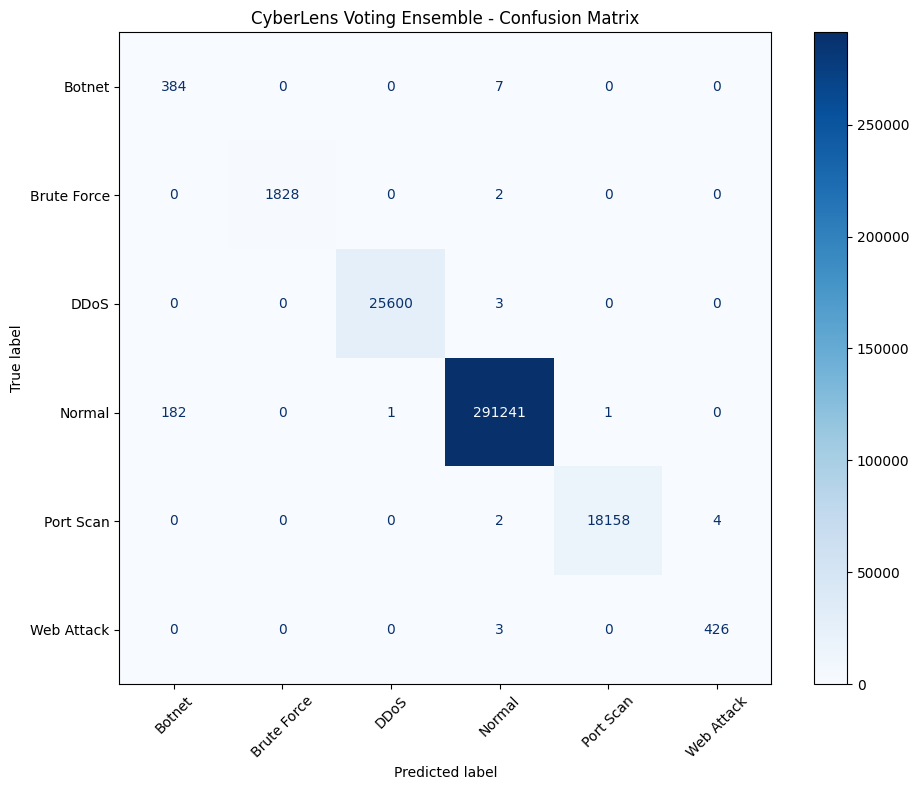


Class-wise Error Analysis
----------------------------------------------------------------------


,Class,Actual Samples,Correct Predictions,Misclassified,Recall,Error Rate (%)
0,Botnet,391,384,7,0.9821,1.79
1,Brute Force,1830,1828,2,0.9989,0.11
2,DDoS,25603,25600,3,0.9999,0.01
3,Normal,291425,291241,184,0.9994,0.06
4,Port Scan,18164,18158,6,0.9997,0.03
5,Web Attack,429,426,3,0.9930,0.70



Most Common Misclassifications
----------------------------------------------------------------------


,Actual Class,Predicted Class,Count
3,Normal,Botnet,182
0,Botnet,Normal,7
7,Port Scan,Web Attack,4
8,Web Attack,Normal,3
2,DDoS,Normal,3
6,Port Scan,Normal,2
1,Brute Force,Normal,2
4,Normal,DDoS,1
5,Normal,Port Scan,1



ERROR ANALYSIS SUMMARY
Total test samples: 337,842
Correct predictions: 337,637
Incorrect predictions: 205
Overall error rate: 0.0607%

Minority Class Performance
----------------------------------------------------------------------
Botnet: Recall = 0.9821, Errors = 7
Web Attack: Recall = 0.9930, Errors = 3

FINAL INTERPRETATION
The confusion matrix provides class-level evidence of the Voting Ensemble's intrusion detection performance.
Particular attention is given to minority attack classes because overall accuracy can hide poor performance on rare attack categories.


In [121]:
# ============================================================
# STEP 27: CONFUSION MATRIX & ERROR ANALYSIS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import mode # Required for ensemble predictions
import joblib # Required for loading models
import os # Required for path manipulation

print("=" * 70)
print("CONFUSION MATRIX & ERROR ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Class names
# ------------------------------------------------------------

class_names = [
    "Botnet",
    "Brute Force",
    "DDoS",
    "Normal",
    "Port Scan",
    "Web Attack"
]


# ------------------------------------------------------------
# 2. Generate confusion matrix
# ------------------------------------------------------------

# Define the directory where models are saved
MODEL_DIR = "cyberlens_models"

# Load the trained models
dt_model = joblib.load(os.path.join(MODEL_DIR, "decision_tree.pkl"))
rf_model = joblib.load(os.path.join(MODEL_DIR, "random_forest.pkl"))
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgboost.pkl"))

# Generate individual model predictions for the ensemble
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Combine predictions from individual models
predictions = np.column_stack([
    y_pred_dt,
    y_pred_rf,
    y_pred_xgb
])

# Majority voting to get the ensemble prediction
ensemble_pred = mode(
    predictions,
    axis=1,
    keepdims=False
).mode

cm = confusion_matrix(
    y_test,
    ensemble_pred,
    labels=range(len(class_names))
)


# ------------------------------------------------------------
# 3. Display numerical confusion matrix
# ------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("\nConfusion Matrix")
print("-" * 70)

display(cm_df)


# ------------------------------------------------------------
# 4. Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "CyberLens Voting Ensemble - Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 5. Calculate class-wise errors
# ------------------------------------------------------------

print("\nClass-wise Error Analysis")
print("-" * 70)

error_results = []

for i, class_name in enumerate(class_names):

    actual = cm[i].sum()

    correct = cm[i, i]

    errors = actual - correct

    recall = (
        correct / actual
        if actual > 0
        else 0
    )

    error_rate = (
        errors / actual * 100
        if actual > 0
        else 0
    )

    error_results.append({

        "Class": class_name,

        "Actual Samples": actual,

        "Correct Predictions": correct,

        "Misclassified": errors,

        "Recall": recall,

        "Error Rate (%)": error_rate
    })


error_df = pd.DataFrame(
    error_results
)

display(
    error_df.style.format({
        "Recall": "{:.4f}",
        "Error Rate (%)": "{:.2f}"
    })
)


# ------------------------------------------------------------
# 6. Identify most common misclassifications
# ------------------------------------------------------------

print("\nMost Common Misclassifications")
print("-" * 70)

misclassification_results = []

for actual_index, actual_class in enumerate(class_names):

    for predicted_index, predicted_class in enumerate(class_names):

        if actual_index != predicted_index:

            count = cm[
                actual_index,
                predicted_index
            ]

            if count > 0:

                misclassification_results.append({

                    "Actual Class": actual_class,

                    "Predicted Class": predicted_class,

                    "Count": count
                })


misclassification_df = pd.DataFrame(
    misclassification_results
)

if len(misclassification_df) > 0:

    misclassification_df = (
        misclassification_df
        .sort_values(
            "Count",
            ascending=False
        )
    )

    display(
        misclassification_df.head(15)
    )

else:

    print(
        "No misclassifications detected."
    )


# ------------------------------------------------------------
# 7. Overall error rate
# ------------------------------------------------------------

total_samples = cm.sum()

correct_predictions = np.trace(cm)

incorrect_predictions = (
    total_samples - correct_predictions
)

overall_error = (
    incorrect_predictions
    / total_samples
) * 100


print("\n" + "=" * 70)
print("ERROR ANALYSIS SUMMARY")
print("=" * 70)

print(
    "Total test samples:",
    f"{total_samples:,}"
)

print(
    "Correct predictions:",
    f"{correct_predictions:,}"
)

print(
    "Incorrect predictions:",
    f"{incorrect_predictions:,}"
)

print(
    "Overall error rate:",
    f"{overall_error:.4f}%"
)


# ------------------------------------------------------------
# 8. Minority class analysis
# ------------------------------------------------------------

print("\nMinority Class Performance")
print("-" * 70)

minority_classes = [
    "Botnet",
    "Web Attack"
]

for class_name in minority_classes:

    row = error_df[
        error_df["Class"] == class_name
    ].iloc[0]

    print(
        f"{class_name}: "
        f"Recall = {row['Recall']:.4f}, "
        f"Errors = {int(row['Misclassified'])}"
    )


print("\n" + "=" * 70)
print("FINAL INTERPRETATION")
print("=" * 70)

print(
    "The confusion matrix provides class-level evidence "
    "of the Voting Ensemble's intrusion detection performance."
)

print(
    "Particular attention is given to minority attack classes "
    "because overall accuracy can hide poor performance on "
    "rare attack categories."
)


FINAL RESULTS VISUALIZATION


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Decision Tree,0.9993,0.9422,0.9922,0.9632,0.9994
1,Random Forest,0.9992,0.9364,0.9920,0.9584,0.9993
2,XGBoost,0.9993,0.9395,0.9972,0.9626,0.9994
3,Voting Ensemble,0.9994,0.9448,0.9955,0.9655,0.9994


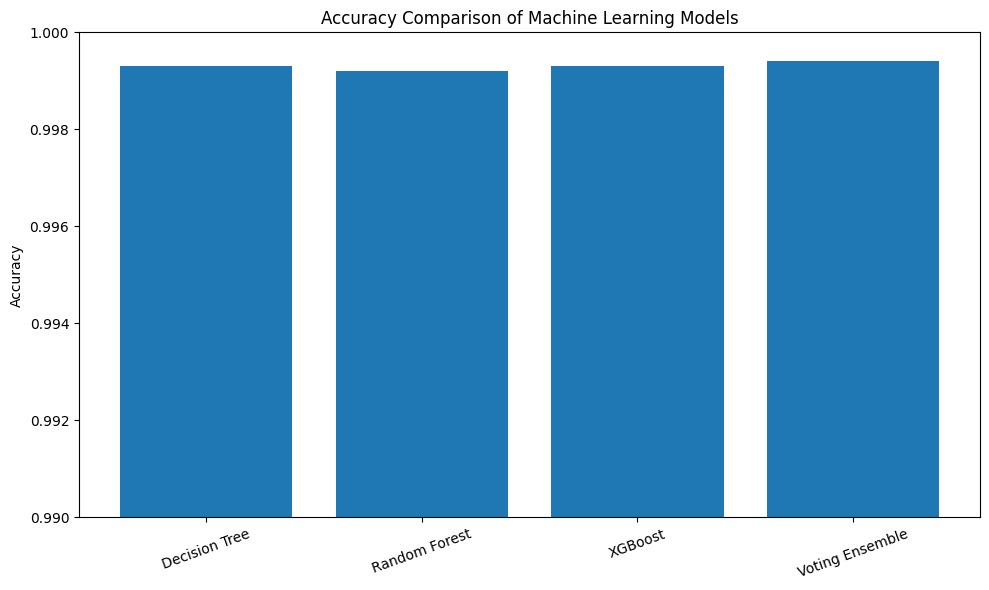

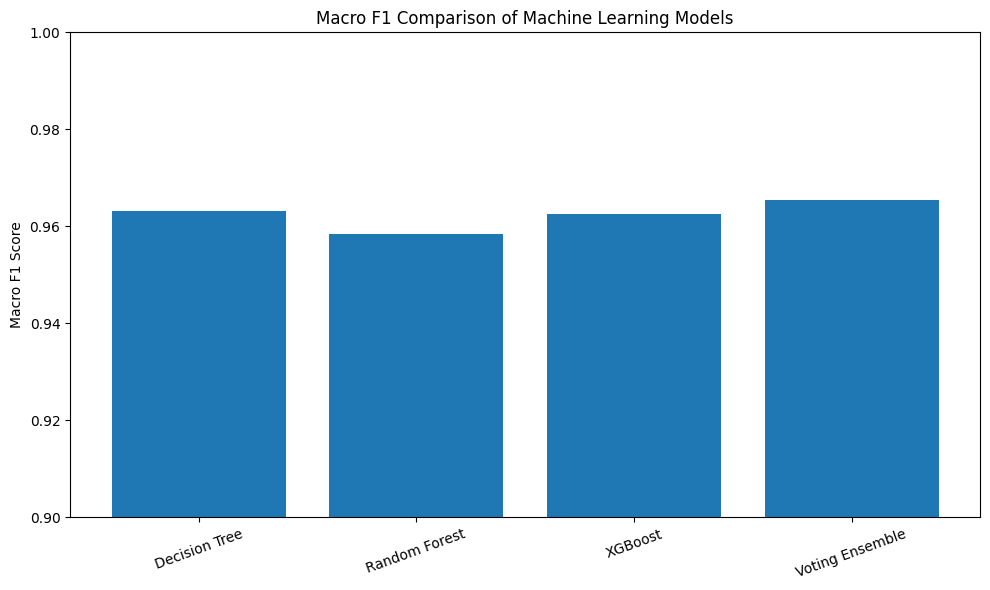

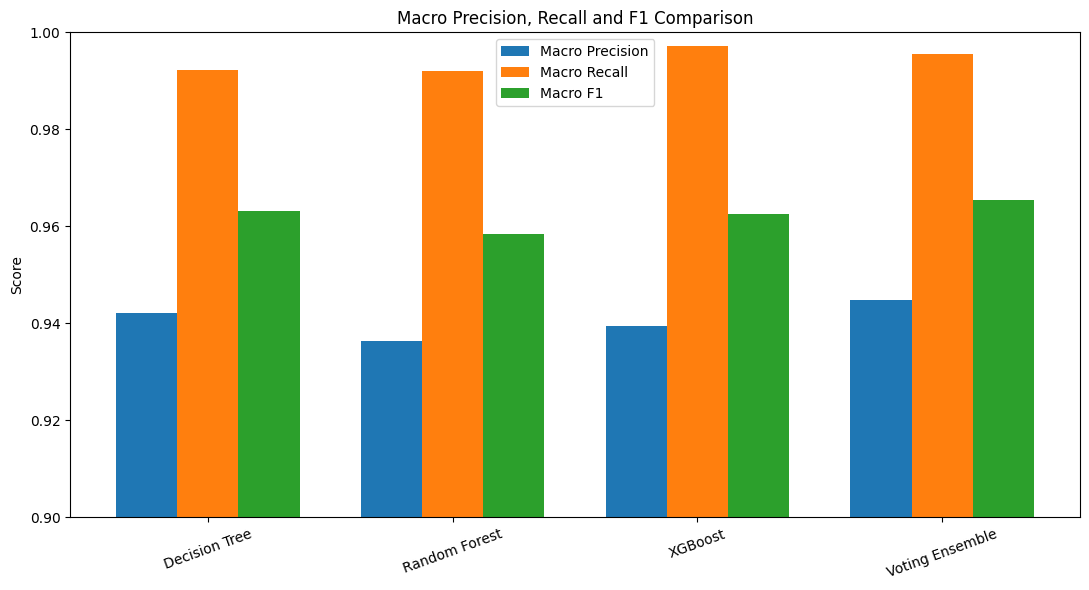

,Class,Decision Tree,Random Forest,XGBoost,Voting Ensemble
0,Botnet,0.8004,0.7672,0.7846,0.8025
1,Brute Force,0.9984,0.9992,0.9997,0.9995
2,DDoS,0.9997,0.9998,0.9999,0.9999
3,Normal,0.9996,0.9996,0.9996,0.9997
4,Port Scan,0.9996,0.9998,0.9998,0.9998
5,Web Attack,0.9815,0.9849,0.9919,0.9919


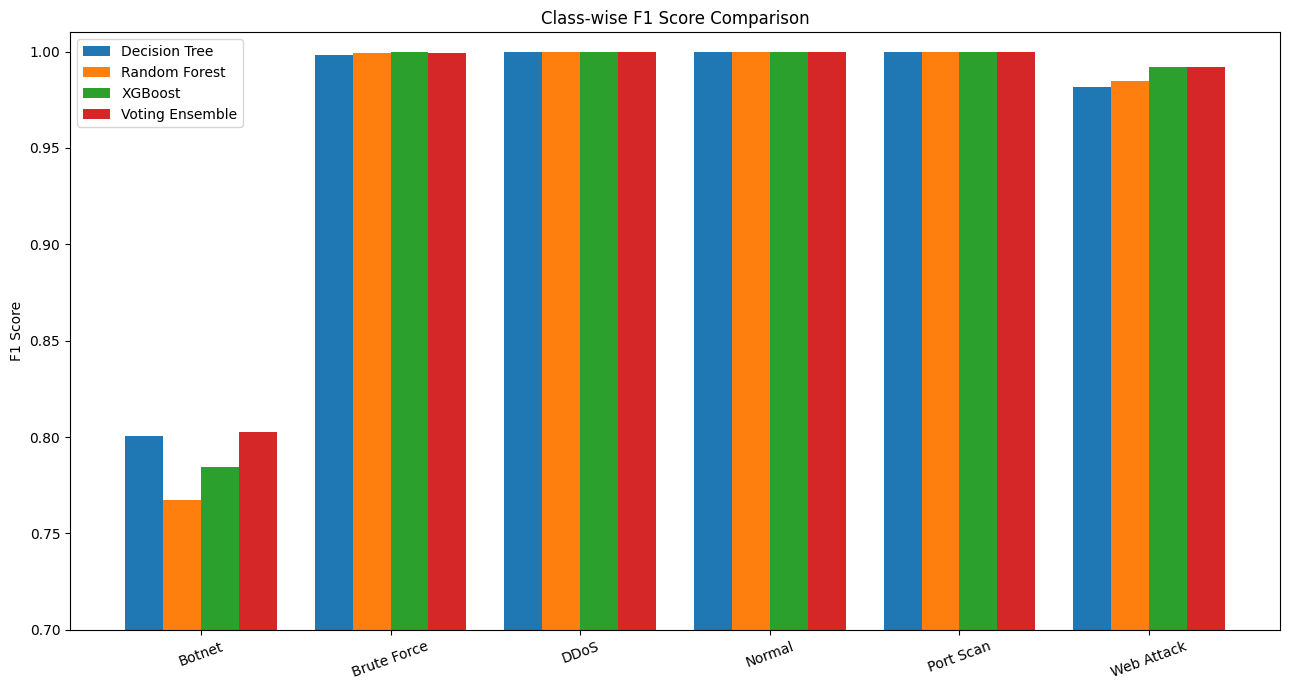

,Metric,XGBoost,Voting Ensemble,Improvement
0,Accuracy,0.999325,0.999393,0.000068
1,Weighted F1,0.999389,0.999444,0.000055


,Fold,Accuracy,Macro F1,Weighted F1
0,Fold 1,0.9992,0.9467,0.9992
1,Fold 2,0.9987,0.8853,0.9985
2,Fold 3,0.9989,0.9346,0.9989


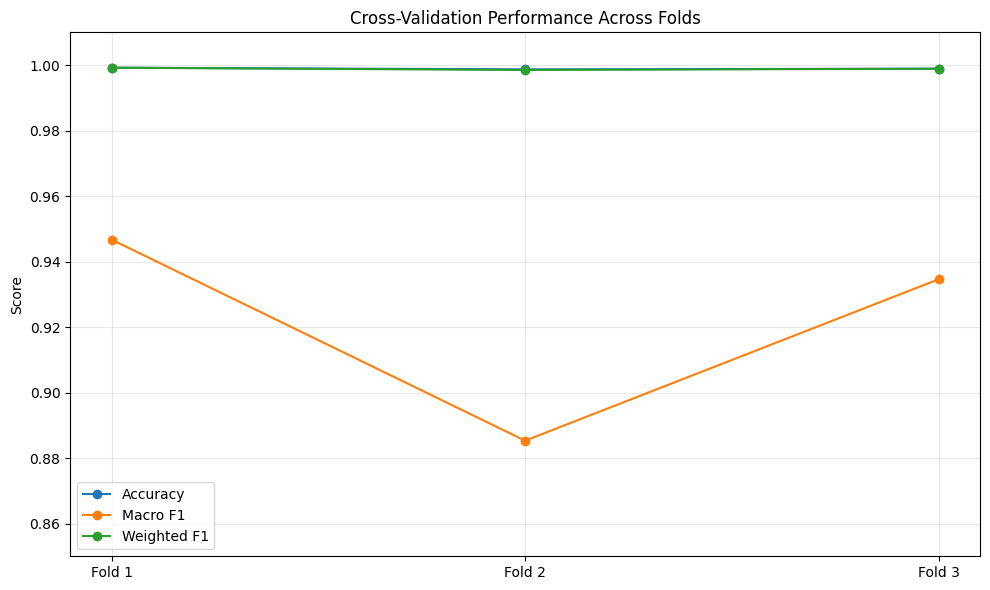


FINAL VISUALIZATION SUMMARY
Best Model: Voting Ensemble
Accuracy: 0.999393
Macro F1: 0.9655
Weighted F1: 0.999444
Accuracy improvement over XGBoost: 0.000068
Weighted F1 improvement over XGBoost: 0.000055

All final evaluation visualizations generated successfully.


In [122]:
# ============================================================
# STEP 28: FINAL RESULTS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("FINAL RESULTS VISUALIZATION")
print("=" * 70)


# ============================================================
# 1. MODEL PERFORMANCE DATA
# ============================================================

model_results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Voting Ensemble"
    ],

    "Accuracy": [
        0.9993,
        0.9992,
        0.9993,
        0.9994
    ],

    "Macro Precision": [
        0.9422,
        0.9364,
        0.9395,
        0.9448
    ],

    "Macro Recall": [
        0.9922,
        0.9920,
        0.9972,
        0.9955
    ],

    "Macro F1": [
        0.9632,
        0.9584,
        0.9626,
        0.9655
    ],

    "Weighted F1": [
        0.9994,
        0.9993,
        0.9994,
        0.9994
    ]
})

display(model_results)


# ============================================================
# 2. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.ylim(
    0.99,
    1.000
)

plt.ylabel("Accuracy")

plt.title(
    "Accuracy Comparison of Machine Learning Models"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()


# ============================================================
# 3. MACRO F1 COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Macro F1"]
)

plt.ylim(
    0.90,
    1.00
)

plt.ylabel("Macro F1 Score")

plt.title(
    "Macro F1 Comparison of Machine Learning Models"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()


# ============================================================
# 4. PRECISION / RECALL / F1 COMPARISON
# ============================================================

x = np.arange(
    len(model_results["Model"])
)

width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    model_results["Macro Precision"],
    width,
    label="Macro Precision"
)

plt.bar(
    x,
    model_results["Macro Recall"],
    width,
    label="Macro Recall"
)

plt.bar(
    x + width,
    model_results["Macro F1"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    model_results["Model"],
    rotation=20
)

plt.ylim(
    0.90,
    1.00
)

plt.ylabel("Score")

plt.title(
    "Macro Precision, Recall and F1 Comparison"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 5. CLASS-WISE F1 COMPARISON
# ============================================================

class_f1 = pd.DataFrame({

    "Class": [
        "Botnet",
        "Brute Force",
        "DDoS",
        "Normal",
        "Port Scan",
        "Web Attack"
    ],

    "Decision Tree": [
        0.8004,
        0.9984,
        0.9997,
        0.9996,
        0.9996,
        0.9815
    ],

    "Random Forest": [
        0.7672,
        0.9992,
        0.9998,
        0.9996,
        0.9998,
        0.9849
    ],

    "XGBoost": [
        0.7846,
        0.9997,
        0.9999,
        0.9996,
        0.9998,
        0.9919
    ],

    "Voting Ensemble": [
        0.8025,
        0.9995,
        0.9999,
        0.9997,
        0.9998,
        0.9919
    ]
})

display(class_f1)


# ============================================================
# 6. CLASS-WISE F1 GRAPH
# ============================================================

x = np.arange(
    len(class_f1["Class"])
)

width = 0.20

plt.figure(figsize=(13, 7))

plt.bar(
    x - 1.5 * width,
    class_f1["Decision Tree"],
    width,
    label="Decision Tree"
)

plt.bar(
    x - 0.5 * width,
    class_f1["Random Forest"],
    width,
    label="Random Forest"
)

plt.bar(
    x + 0.5 * width,
    class_f1["XGBoost"],
    width,
    label="XGBoost"
)

plt.bar(
    x + 1.5 * width,
    class_f1["Voting Ensemble"],
    width,
    label="Voting Ensemble"
)

plt.xticks(
    x,
    class_f1["Class"],
    rotation=20
)

plt.ylim(
    0.70,
    1.01
)

plt.ylabel("F1 Score")

plt.title(
    "Class-wise F1 Score Comparison"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 7. ENSEMBLE IMPROVEMENT
# ============================================================

xgb_accuracy = 0.999325
ensemble_accuracy = 0.999393

xgb_f1 = 0.999389
ensemble_f1 = 0.999444

accuracy_improvement = (
    ensemble_accuracy - xgb_accuracy
)

f1_improvement = (
    ensemble_f1 - xgb_f1
)

improvement_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Weighted F1"
    ],

    "XGBoost": [
        xgb_accuracy,
        xgb_f1
    ],

    "Voting Ensemble": [
        ensemble_accuracy,
        ensemble_f1
    ],

    "Improvement": [
        accuracy_improvement,
        f1_improvement
    ]
})

display(
    improvement_df.style.format({
        "XGBoost": "{:.6f}",
        "Voting Ensemble": "{:.6f}",
        "Improvement": "{:.6f}"
    })
)


# ============================================================
# 8. CROSS-VALIDATION STABILITY
# ============================================================

cv_results = pd.DataFrame({

    "Fold": [
        "Fold 1",
        "Fold 2",
        "Fold 3"
    ],

    "Accuracy": [
        0.9992,
        0.9987,
        0.9989
    ],

    "Macro F1": [
        0.9467,
        0.8853,
        0.9346
    ],

    "Weighted F1": [
        0.9992,
        0.9985,
        0.9989
    ]
})

display(cv_results)


# ============================================================
# 9. CROSS-VALIDATION GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    cv_results["Fold"],
    cv_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    cv_results["Fold"],
    cv_results["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    cv_results["Fold"],
    cv_results["Weighted F1"],
    marker="o",
    label="Weighted F1"
)

plt.ylim(
    0.85,
    1.01
)

plt.ylabel("Score")

plt.title(
    "Cross-Validation Performance Across Folds"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL VISUALIZATION SUMMARY")
print("=" * 70)

print(
    "Best Model: Voting Ensemble"
)

print(
    "Accuracy:",
    f"{ensemble_accuracy:.6f}"
)

print(
    "Macro F1:",
    f"{0.9655:.4f}"
)

print(
    "Weighted F1:",
    f"{ensemble_f1:.6f}"
)

print(
    "Accuracy improvement over XGBoost:",
    f"{accuracy_improvement:.6f}"
)

print(
    "Weighted F1 improvement over XGBoost:",
    f"{f1_improvement:.6f}"
)

print(
    "\nAll final evaluation visualizations generated successfully."
)

In [123]:
# ============================================================
# STEP 29: FINAL EXPERIMENTAL RESULTS
# ============================================================

import pandas as pd

print("=" * 80)
print("CYBERLENS - FINAL EXPERIMENTAL RESULTS")
print("=" * 80)


# ------------------------------------------------------------
# 1. Final model comparison
# ------------------------------------------------------------

final_results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Voting Ensemble"
    ],

    "Accuracy": [
        0.9993,
        0.9992,
        0.9993,
        0.9994
    ],

    "Macro Precision": [
        0.9422,
        0.9364,
        0.9395,
        0.9448
    ],

    "Macro Recall": [
        0.9922,
        0.9920,
        0.9972,
        0.9955
    ],

    "Macro F1": [
        0.9632,
        0.9584,
        0.9626,
        0.9655
    ],

    "Weighted F1": [
        0.9994,
        0.9993,
        0.9994,
        0.9994
    ]
})


print("\nFINAL MODEL COMPARISON")
print("-" * 80)

display(
    final_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 2. Identify best model for each metric
# ------------------------------------------------------------

print("\nBEST MODEL BY METRIC")
print("-" * 80)

metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]

for metric in metrics:

    best_index = final_results[metric].idxmax()

    best_model = final_results.loc[
        best_index,
        "Model"
    ]

    best_value = final_results.loc[
        best_index,
        metric
    ]

    print(
        f"{metric:<20}: "
        f"{best_model:<20} "
        f"{best_value:.4f}"
    )


# ------------------------------------------------------------
# 3. Final selected model
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MODEL SELECTION")
print("=" * 80)

best_model = final_results.loc[
    final_results["Macro F1"].idxmax(),
    "Model"
]

print(
    "Selected Model:",
    best_model
)

print(
    "Selection Criterion: Highest Macro F1"
)

print(
    "Macro F1:",
    f"{final_results['Macro F1'].max():.4f}"
)


# ------------------------------------------------------------
# 4. Robustness results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ROBUSTNESS VALIDATION")
print("=" * 80)

robustness = pd.DataFrame({

    "Validation": [
        "Train-Test Exact Overlap",
        "Duplicate Test Records",
        "Constant Features",
        "Features with KS > 0.10",
        "Mean KS Statistic",
        "Median KS Statistic"
    ],

    "Result": [
        "0",
        "0",
        "0",
        "0 / 67",
        "0.0063",
        "0.0058"
    ],

    "Status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS"
    ]
})

display(robustness)


# ------------------------------------------------------------
# 5. Cross-validation results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CROSS-VALIDATION RESULTS")
print("=" * 80)

cv_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ],

    "Mean": [
        0.9989,
        0.9222,
        0.9989
    ],

    "Std Dev": [
        0.0003,
        0.0325,
        0.0004
    ]
})

display(
    cv_summary.style.format({
        "Mean": "{:.4f}",
        "Std Dev": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 6. Ensemble improvement
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ENSEMBLE IMPROVEMENT")
print("=" * 80)

print(
    "XGBoost Accuracy   : 0.999325"
)

print(
    "Ensemble Accuracy  : 0.999393"
)

print(
    "Accuracy Improvement: +0.000068"
)

print()

print(
    "XGBoost Weighted F1   : 0.999389"
)

print(
    "Ensemble Weighted F1  : 0.999444"
)

print(
    "Weighted F1 Improvement: +0.000055"
)


# ------------------------------------------------------------
# 7. Final project summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CYBERLENS FINAL SUMMARY")
print("=" * 80)

print("""
1. Multiple supervised learning models were evaluated.

2. Decision Tree, Random Forest and XGBoost achieved
   very high classification performance.

3. A majority-voting ensemble was constructed to combine
   the predictions of the tree-based models.

4. The Voting Ensemble achieved the highest Macro F1
   among the evaluated models.

5. SHAP was used to provide feature-level explanations
   for individual predictions.

6. Cross-validation was performed to evaluate model
   stability across different folds.

7. Train-test overlap and feature/label leakage checks
   did not identify direct data leakage.

8. Train-test feature distributions were highly similar,
   with a mean KS statistic of 0.0063.

9. The final CyberLens system integrates detection,
   ensemble prediction, explainability and visualization.
""")

CYBERLENS - FINAL EXPERIMENTAL RESULTS

FINAL MODEL COMPARISON
--------------------------------------------------------------------------------


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Decision Tree,0.9993,0.9422,0.9922,0.9632,0.9994
1,Random Forest,0.9992,0.9364,0.9920,0.9584,0.9993
2,XGBoost,0.9993,0.9395,0.9972,0.9626,0.9994
3,Voting Ensemble,0.9994,0.9448,0.9955,0.9655,0.9994



BEST MODEL BY METRIC
--------------------------------------------------------------------------------
Accuracy            : Voting Ensemble      0.9994
Macro Precision     : Voting Ensemble      0.9448
Macro Recall        : XGBoost              0.9972
Macro F1            : Voting Ensemble      0.9655
Weighted F1         : Decision Tree        0.9994

FINAL MODEL SELECTION
Selected Model: Voting Ensemble
Selection Criterion: Highest Macro F1
Macro F1: 0.9655

ROBUSTNESS VALIDATION


,Validation,Result,Status
0,Train-Test Exact Overlap,0,PASS
1,Duplicate Test Records,0,PASS
2,Constant Features,0,PASS
3,Features with KS > 0.10,0 / 67,PASS
4,Mean KS Statistic,0.0063,PASS
5,Median KS Statistic,0.0058,PASS



CROSS-VALIDATION RESULTS


,Metric,Mean,Std Dev
0,Accuracy,0.9989,0.0003
1,Macro F1,0.9222,0.0325
2,Weighted F1,0.9989,0.0004



ENSEMBLE IMPROVEMENT
XGBoost Accuracy   : 0.999325
Ensemble Accuracy  : 0.999393
Accuracy Improvement: +0.000068

XGBoost Weighted F1   : 0.999389
Ensemble Weighted F1  : 0.999444
Weighted F1 Improvement: +0.000055

CYBERLENS FINAL SUMMARY

1. Multiple supervised learning models were evaluated.

2. Decision Tree, Random Forest and XGBoost achieved
   very high classification performance.

3. A majority-voting ensemble was constructed to combine
   the predictions of the tree-based models.

4. The Voting Ensemble achieved the highest Macro F1
   among the evaluated models.

5. SHAP was used to provide feature-level explanations
   for individual predictions.

6. Cross-validation was performed to evaluate model
   stability across different folds.

7. Train-test overlap and feature/label leakage checks
   did not identify direct data leakage.

8. Train-test feature distributions were highly similar,
   with a mean KS statistic of 0.0063.

9. The final CyberLens system integrates detecti